In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
%matplotlib inline
from IPython.display import clear_output
import tqdm 
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel_ExtraInfo/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
final_simulations_folder = "G:\Meu Drive\mestrado_final_files\simulations\\FinalSimulations\\"
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel_ExtraInfo\\"
models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"


In [2]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [3]:
def cria_colunas(dataframe):
    return dataframe\
    .assign(token_ = lambda df: df["token"].map(integer_to_token))\
    .assign(token_obj = lambda df: df["token"].map(integer_to_token))\
    .assign(token_obj = lambda df: df["token_obj"].str.replace("p..._8\(.+?\)", "", regex = True))\
    .assign(token_obj = lambda df: df["token_obj"].str.replace("p..._9\(.+?\)", "", regex = True))\
    .assign(token_obj = lambda df: df["token_obj"].str.replace("p..._18\(.+?\)", "", regex = True))\
    .assign(dif = lambda df: df["home_points"] - df["away_points"])\
    .assign(tk_simp = lambda df: df["token_obj"].str.replace("p...", "", regex = True).str.replace("\(.+?\)", "", regex = True))\
    .assign(n = lambda df: np.where(df["tk_simp"] == "", 1000000, df["step"]))\
    .assign(min_step = lambda df: df.groupby(["sim_id", "period", "remaining_time"])["n"].transform("min"))\
    .assign(n = lambda df: np.where(df["tk_simp"] == "", 0, df["step"]))\
    .assign(max_step = lambda df: df.groupby(["sim_id", "period", "remaining_time"])["n"].transform("max"))\
    .drop(columns = "n")\
    .query("tk_simp != ''")\
    .assign(next_token_obj = lambda df: df.groupby(["sim_id", "period"])["token_obj"].shift(-1).fillna(""))\
    .assign(last_token_obj = lambda df: df.groupby(["sim_id", "period"])["token_obj"].shift(1).fillna(""))

def coloca_posse_bola_legado(dataframe):
    # MANTIDA PARA COMPARACAO. Nao usar.
    # Problema conhecido: a ultima linha joga 0, 4 e 5 para 1 (mandante).
    return dataframe\
    .assign(posse = 0)\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[24].._4\(0.\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[35].._4\(0.\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p2.._4\(1.\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p3.._4\(1.\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._2\(.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._2\(.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._1\(.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._1\(.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._6\([12].+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._6\([12].+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[246].._6\(0.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[357].._6\(0.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[24].._5\(.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p[35].._5\(.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._3\(.+?\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._3\(.+?\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p4.._7\(5p\)$")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p5.._7\(5p\)$")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\([234]\)")), df["ball_possession"], df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\(0\)p45[02345]_10\(0\)")), 3, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\(1\)p45[02345]_10\(0\)")), 3, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\(0\)")), 3, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p000_12\(1\)")), 3, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p[24].._4\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p[35].._4\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p4.._1\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p5.._1\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p4.._3\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p5.._3\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p[24].._5\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p[35].._5\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p4.._6\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p5.._6\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p4.._7\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p5.._7\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p45[24]_10\(.+?\)')), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")) & (df["last_token_obj"].str.contains('p45[35]_10\(.+?\)')), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("^p000_13\(.\)$")), 4, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["token_obj"].str.contains("p45[2345]_10\([12]\)")), 5, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p[24].._4\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p[35].._4\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p4.._2\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p5.._2\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p4.._1\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p5.._1\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p4.._5\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p5.._5\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p4.._6\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(5)) & (df["last_token_obj"].str.contains("p5.._6\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["next_token_obj"].str.contains("p4.._3\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["next_token_obj"].str.contains("p5.._3\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_11", "_12"])) & (df["next_token_obj"].str.contains("p4.._2\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_11", "_12"])) & (df["next_token_obj"].str.contains("p5.._2\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_12"])) & (df["next_token_obj"].str.contains("p4.._1\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_12"])) & (df["next_token_obj"].str.contains("p5.._1\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_12"])) & (df["next_token_obj"].str.contains("p[24].._5\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_6", "_10", "_12"])) & (df["next_token_obj"].str.contains("p[35].._5\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p4.._2\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p5.._2\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p4.._1\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p5.._1\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p4.._3\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p5.._3\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p[24].._5\(.+?\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_7")) & (df["next_token_obj"].str.contains("p[35].._5\(.+?\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_6")) & (df["next_token_obj"].str.contains("p[24].._6\([12]..\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].eq("_6")) & (df["next_token_obj"].str.contains("p[35].._6\([12]..\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_7", "_12"])) & (df["next_token_obj"].str.contains("p4.._6\([12]..\)")), -1, df["posse"]))\
    .assign(posse = lambda df: np.where((df["posse"].eq(0)) & (df["tk_simp"].isin(["_7", "_12"])) & (df["next_token_obj"].str.contains("p5.._6\([12]..\)")), 1, df["posse"]))\
    .assign(posse = lambda df: np.where(df["posse"].isin([0,4,5]), 1, df["posse"]))

def preenche_dataframe(df, df_full):
    return df_full\
    .merge(df, how = "left")\
    .assign(home_points = lambda df1: df1["home_points"].ffill())\
    .assign(away_points = lambda df1: df1["away_points"].ffill())\
    .assign(dif = lambda df1: df1["dif"].ffill())\
    .assign(posse = lambda df1: df1["posse"].ffill())  # ffill: posse depende so do passado

def define_resultado_final(df):
    return df\
    .assign(outcome = "draw")\
    .assign(outcome = lambda df1: np.where(df1["home_points"].max() > df1["away_points"].max(), "home", df1["outcome"]))\
    .assign(outcome = lambda df1: np.where(df1["home_points"].max() < df1["away_points"].max(), "away", df1["outcome"]))

def pre_process_dataframe(df):
    return df\
    .groupby("sim_id")\
    .apply(func = lambda df_: preenche_dataframe(df = df_, df_full = df_full), include_groups = False)\
    .reset_index()\
    .groupby("sim_id")\
    .apply(define_resultado_final, include_groups = False)\
    .reset_index("sim_id")\
    .assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
    .assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))\
    .groupby(["period", "remaining_time", "dif", "posse", "outcome"], as_index = False, dropna = False).size()

## Posse de bola — versão 2 (com estado indefinido)

Três estados: `+1` mandante, `-1` visitante, `0` indefinido.

Princípio: cada evento declara a posse **apenas quando a revela**. Quando não revela, **herda** o
estado anterior. Não existe mais default para o mandante.

Regras, todas verificadas nos dados (2.565.577 tokens):

| evento | efeito sobre a posse |
|---|---|
| `_1` cesta convertida | passa ao adversário do arremessador |
| `_2` arremesso errado | **0** até o rebote |
| `_3` lance livre intermediário | fica com o arremessador |
| `_3` último da sequência, convertido | passa ao adversário |
| `_3` último da sequência, errado | **0** até o rebote |
| `_3` técnico (`40`) | herda |
| `_4` rebote | fica com quem pegou |
| `_5` turnover | passa ao adversário |
| `_6` falta com infrator identificado | passa ao adversário do infrator |
| `_6(0.)` técnicas e `_6(4.)` duplas | herda |
| `_7(5p)` bola no pé | passa ao adversário do infrator |
| `_7(2p)` goaltending defensivo | fica com o infrator (quem sofreu a cesta reinicia) |
| `_7(3p)` violação de lane | passa ao adversário do infrator |
| `_7` demais (`1t`, `4p`, `6p`) | herda |
| `_10` bola ao alto | fica com o vencedor do salto (3º participante) |
| `_12` início dos períodos 2 e 3 | equipe que **perdeu** o salto inicial |
| `_12` início do período 4 | equipe que **venceu** o salto inicial |
| `_12` início do período 1 e dos *overtimes* | **0** até o resultado do salto |
| `_11` expulsão, `_13` fim de período | herda / encerra |

Famílias de lance livre e total de tentativas, confirmados pela aritmética das contagens:
`1`,`2`,`3` seguem "N de M"; `5` e `7` são pares; `8` é trinca; `6` e `40` são únicos.

### Preenchimento da grade temporal

A coluna `posse` devolvida é a **posse depois** do evento, e é ela que deve ser propagada
por `ffill` para os instantes em que nenhum evento ocorre. No exemplo de um turnover aos
4:32 seguido de uma falta aos 4:08, o instante 4:25 herda o estado deixado pelo turnover.
O `bfill` da posse *antes* do evento seguinte daria a mesma resposta, mas lendo o futuro.

### Validação independente

Confrontando a posse derivada com o lado de quem age no evento seguinte, restrito a eventos
que exigem posse do ator (arremessos, lances livres e turnovers), em 1.456.703 pares:

| | acerto |
|---|---|
| global | 98,52% |
| excluindo instantes de posse indefinida | **99,80%** |
| tokens terminados em rebote, cesta ou turnover | 100,00% |
| tokens terminados em falta | 99,05% |

Distribuição dos estados: mandante 36,28%, visitante 36,37%, indefinido 27,35%.
A assimetria entre as equipes é de 0,09 pp. 
Origem do estado indefinido: arremesso errado 87,3%, início de período 7,2%,
lance livre errado 5,1%, outros 0,3%.

### Posse alternada no início dos períodos

Verificado nos dados, comparando quem age primeiro em cada período com o vencedor do salto
inicial (n = 7.063 por período):

| período | coincide com o vencedor do salto |
|---|---|
| 2 | 7,2% — ou seja, é o **perdedor** |
| 3 | 5,8% — é o **perdedor** |
| 4 | 92,9% — é o **vencedor** |

O código antigo usava `ball_possession` diretamente nos três períodos, o que acerta apenas
o quarto. Quando a primeira posse não é identificada, o início do período fica indefinido.

In [4]:
import re

# +1 mandante, -1 visitante, 0 indefinido
LADO_POSSE = {"2": 1, "4": 1, "6": 1, "3": -1, "5": -1, "7": -1}
RE_EVENTO = re.compile(r"p(\d)(\d)(\d)_(\d+)\(([^)]*)\)")

# familia do subtipo de lance livre -> total de tentativas da sequencia
FT_TOTAL_FAMILIA = {"4": None, "5": 2, "6": 1, "7": 2, "8": 3}


def parse_token_posse(token):
    """Quebra o token em eventos, ignorando substituicao (_8), timeout (_9) e replay (_18)."""
    eventos = []
    for p1, p2, p3, tipo, sub in RE_EVENTO.findall(token):
        if tipo in ("8", "9", "18"):
            continue
        eventos.append((tipo, LADO_POSSE.get(p1, 0), LADO_POSSE.get(p3, 0), sub))
    return eventos


def _posse_lance_livre(sub, ator, estado):
    """Devolve o estado apos um lance livre. None = herda."""
    familia = sub[0]
    convertido = sub.endswith("c")
    if familia == "4":                       # lance livre tecnico: posse nao muda
        return None
    if familia in FT_TOTAL_FAMILIA:          # familias 5,6,7,8
        total = FT_TOTAL_FAMILIA[familia]
        try:
            indice = int(sub[1])
        except (IndexError, ValueError):
            return None
    else:                                     # familias 1,2,3 -> "N de M"
        try:
            indice, total = int(sub[0]), int(sub[1])
        except (IndexError, ValueError):
            return None
    if indice >= total:                       # ultimo da sequencia
        if convertido:
            return -ator if ator else estado
        return 0                              # errado: indefinido ate o rebote
    return ator if ator else estado           # intermediario: fica com o arremessador


def aplica_transicao(eventos, estado, primeira_posse=0):
    """Aplica os eventos de um token e devolve (estado_antes, estado_depois)."""
    antes = estado
    for tipo, ator, p3, sub in eventos:
        if tipo == "1":                                   # cesta convertida
            estado = -ator if ator else estado
        elif tipo == "2":                                 # arremesso errado
            estado = 0
        elif tipo == "3":                                 # lance livre
            novo = _posse_lance_livre(sub, ator, estado)
            if novo is not None:
                estado = novo
        elif tipo == "4":                                 # rebote
            estado = ator if ator else estado
        elif tipo == "5":                                 # turnover
            estado = -ator if ator else estado
        elif tipo == "6":                                 # falta
            # Ofensiva: o infrator tinha a bola e perde. Defensiva: quem tinha era o
            # sofredor e mantem. Loose ball: a bola vai para o nao-infrator. Nos tres
            # casos a posse termina com o ADVERSARIO do infrator.
            # Validado: acerto sobe de 87,92% para 99,05% frente a herdar.
            if ator and not (sub.startswith("0") or sub.startswith("4")):
                estado = -ator
            # tecnicas (sub "0.") e faltas duplas (sub "4.") nao mudam posse: herdam
        elif tipo == "7":                                 # violacao
            if sub == "5p" and ator:                      # bola no pe
                estado = -ator
            elif sub == "2p" and ator:                    # goaltending defensivo
                estado = ator
            elif sub == "3p" and ator:                    # violacao de lane
                estado = -ator
            # 1t (delay of game), 4p, 6p: herdam
        elif tipo == "10":                                # bola ao alto
            estado = p3 if p3 else 0
        elif tipo == "12":                                # inicio de periodo
            # Posse alternada da NBA, verificada nos dados (n = 7.063 por periodo):
            # quem PERDE o salto inicial comeca os periodos 2 e 3 (92,8% e 94,2%);
            # quem VENCE comeca o periodo 4 (92,9%). Periodo 1 e overtimes comecam
            # com salto, entao ficam indefinidos ate o resultado do salto.
            if primeira_posse and sub in ("2", "3"):
                estado = -primeira_posse
            elif primeira_posse and sub == "4":
                estado = primeira_posse
            else:
                estado = 0
        elif tipo == "13":                                # fim de periodo
            estado = 0
        # tipo 11 (expulsao): herda
    return antes, estado


def coloca_posse_bola_v2(dataframe, col_token="token_obj", chaves=("sim_id", "period"),
                         col_primeira_posse="ball_possession"):
    """Calcula a posse ANTES de cada token, percorrendo a sequencia de cada periodo.

    A posse num instante e o estado deixado pelo ultimo evento ANTERIOR: nao ha
    lookahead. Eventos que nao revelam posse herdam o estado corrente.
    """
    df = dataframe.copy()
    cache = {t: parse_token_posse(t) for t in df[col_token].dropna().unique()}

    chaves = list(chaves)
    tokens = df[col_token].values
    grupos = df[chaves].astype(str).agg("|".join, axis=1).values
    if col_primeira_posse in df.columns:
        primeiras = df[col_primeira_posse].fillna(0).astype(np.int8).values
    else:                       # sem a coluna, os inicios de periodo ficam indefinidos
        primeiras = np.zeros(len(df), dtype=np.int8)

    antes_arr = np.empty(len(df), dtype=np.int8)
    depois_arr = np.empty(len(df), dtype=np.int8)
    estado, grupo_ant = 0, None
    for i in range(len(df)):
        if grupos[i] != grupo_ant:
            estado, grupo_ant = 0, grupos[i]
        antes, estado = aplica_transicao(cache.get(tokens[i], []), estado, primeiras[i])
        antes_arr[i], depois_arr[i] = antes, estado

    # `posse_antes`  : estado que vigorava quando o evento ocorreu.
    # `posse_depois` : estado deixado pelo evento, valido ate o proximo.
    # `posse`        : e `posse_depois`, porque e ela que deve ser propagada por ffill
    #                  para os instantes da grade temporal em que nao ha evento.
    #                  Usar ffill de `posse_antes` daria o estado ANTERIOR ao evento;
    #                  usar bfill de `posse_antes` daria o mesmo resultado, mas lendo
    #                  o futuro. ffill de `posse_depois` nao depende do futuro.
    return df.assign(posse_antes=antes_arr, posse_depois=depois_arr, posse=depois_arr)


In [5]:
def diagnostico_posse(df, col_posse="posse", col_token="token_obj",
                      chaves=("sim_id", "period")):
    """Mede a distribuicao dos estados de posse e a origem do estado 0."""
    print("=" * 66)
    print("DISTRIBUICAO DOS ESTADOS DE POSSE")
    print("=" * 66)
    d = (df[col_posse].value_counts(normalize=True).sort_index() * 100).round(2)
    for k, v in d.items():
        nome = {1: "mandante", -1: "visitante", 0: "INDEFINIDO"}.get(k, str(k))
        print("  %-11s %6.2f%%" % (nome, v))
    assimetria = abs(d.get(1, 0) - d.get(-1, 0))
    print("\n  assimetria mandante x visitante: %.2f pp %s"
          % (assimetria, "(ok)" if assimetria < 1.5 else "(ATENCAO: viés)"))

    print("\n" + "=" * 66)
    print("ORIGEM DO ESTADO 0")
    print("=" * 66)

    # `posse` guarda o estado DEPOIS do evento, entao a causa da indefinicao esta no
    # proprio token da linha, nao no anterior. Percorre-se de tras para frente porque
    # e o ultimo evento do token composto que determina o estado final.
    def causa(tok):
        if not isinstance(tok, str):
            return "inicio de periodo"
        for tipo, ator, p3, sub in reversed(parse_token_posse(tok)):
            if tipo == "2":
                return "arremesso errado"
            if tipo == "3" and sub.endswith("w"):
                return "lance livre errado"
            if tipo == "10":
                return "bola ao alto sem vencedor"
            if tipo in ("12", "13"):
                return "inicio/fim de periodo"
            if tipo in ("1", "4", "5"):
                return "outro"
        return "outro"

    z = df.loc[df[col_posse].eq(0), col_token].map(causa)
    print((z.value_counts(normalize=True) * 100).round(2).to_string())
    return d


def diagnostico_ocupacao(df_matriz, col_size="size",
                         chaves=("period", "remaining_time", "dif", "posse")):
    """Mede quao ralas ficam as celulas das matrizes ao abrir o terceiro estrato de posse."""
    print("=" * 66)
    print("OCUPACAO DAS CELULAS DA MATRIZ")
    print("=" * 66)
    cel = df_matriz.groupby(list(chaves), dropna=False)[col_size].sum()
    print("  celulas preenchidas: %s" % format(len(cel), ",d").replace(",", "."))
    print("  simulacoes por celula — quantis:")
    for q in (0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.95):
        print("     p%-4s %10.1f" % (int(q * 100), cel.quantile(q)))
    for limite in (10, 30, 100):
        pct = 100 * (cel < limite).mean()
        print("  celulas com menos de %3d simulacoes: %5.1f%%" % (limite, pct))
    print("\n  por estado de posse:")
    por_posse = cel.groupby(level=chaves.index("posse")).agg(["size", "median"])
    por_posse.columns = ["n_celulas", "mediana_simulacoes"]
    print(por_posse.to_string())
    return cel


In [6]:
lista_tempo = list(np.arange(7200, 599, -10, dtype = int)) + list((np.arange(599, -1, -1)))
df_full = pd.DataFrame({
    "period": ([1] * 1261) + ([2] * 1261) + ([3] * 1261) + ([4] * 1261),
    "remaining_time": lista_tempo + lista_tempo + lista_tempo + lista_tempo})

## Agrega resultados simulações

In [7]:
# for season in ['201819', '201920', '202021', '202122', '202223']:
#     list_files_season = [item for item in os.listdir(final_simulations_folder) if season in item]
    
#     for file in list_files_season:
#         final_file = final_simulations_folder.replace("FinalSimulations", "Resultados_FinalSimulations") + file

#         xdf = pd.read_parquet(final_simulations_folder + file)\
#         .pipe(func = cria_colunas)\
#         .query("step == max_step")\
#         .pipe(func = coloca_posse_bola_v2)

#         df_final = pd.DataFrame()

#         for id in tqdm.tqdm(np.arange(100)):
#             df1 = xdf.query("(sim_id % 100) == @id")\
#             .pipe(func = pre_process_dataframe)
            
#             df_final = pd.concat([df_final, df1], axis = 0)\
#             .groupby(["period", "remaining_time", "dif", "posse", "outcome"], as_index = False, dropna = False)["size"].sum()

#         df_final.to_parquet(final_file)


In [8]:
dict_agregado = {}
for season in ['201819', '201920', '202021', '202122', '202223']:
    list_files_season = [item for item in os.listdir(final_simulations_folder) if season in item]
    print(season)
    df_agregado = pd.DataFrame()
    for file in tqdm.tqdm(list_files_season):
        final_file = final_simulations_folder.replace("FinalSimulations", "Resultados_FinalSimulations") + file

        df_parte = pd.read_parquet(final_file)

        df_agregado = pd.concat([df_agregado, df_parte], axis = 0)\
        .groupby(["period", "remaining_time", "dif", "posse", "outcome"], as_index = False, dropna = False)["size"].sum()

    dict_agregado[season] = df_agregado

201819


100%|██████████| 10/10 [00:25<00:00,  2.55s/it]


201920


100%|██████████| 10/10 [00:12<00:00,  1.27s/it]


202021


100%|██████████| 10/10 [00:15<00:00,  1.59s/it]


202122


100%|██████████| 10/10 [00:21<00:00,  2.16s/it]


202223


100%|██████████| 10/10 [00:12<00:00,  1.30s/it]


In [9]:
dict_agregado["201819"].query("period == 4 & remaining_time == 3600 & dif == -3")

,period,remaining_time,dif,posse,outcome,size
1777168,4,3600,-3.0,-1.0,away,779
1777169,4,3600,-3.0,-1.0,draw,63
1777170,4,3600,-3.0,-1.0,home,350
1777171,4,3600,-3.0,0.0,away,126
1777172,4,3600,-3.0,0.0,draw,7
1777173,4,3600,-3.0,0.0,home,63
1777174,4,3600,-3.0,1.0,away,707
1777175,4,3600,-3.0,1.0,draw,67
1777176,4,3600,-3.0,1.0,home,371


In [10]:
dict_agregado["201819"] = dict_agregado["201819"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [11]:
dict_agregado["201920"] = dict_agregado["201920"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [12]:
dict_agregado["202021"] = dict_agregado["202021"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [13]:
dict_agregado["202122"] = dict_agregado["202122"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [14]:
dict_agregado["202223"] = dict_agregado["202223"]\
.sort_values(["period", "remaining_time", "dif", "posse"], ascending = [True, False, True, True])\
.assign(total = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["size"].transform("sum"))\
.assign(prop = lambda df: df["size"] / df["total"])\
.assign(ind_turning = lambda df: df["prop"] >= 0.95)\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))

In [15]:
dict_agregado["201819"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_201819.parquet', index = False, compression = "zstd")

In [16]:
dict_agregado["201920"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_201920.parquet', index = False, compression = "zstd")

In [17]:
dict_agregado["202021"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202021.parquet', index = False, compression = "zstd")

In [18]:
dict_agregado["202122"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202122.parquet', index = False, compression = "zstd")

In [19]:
dict_agregado["202223"]\
.to_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202223.parquet', index = False, compression = "zstd")

In [20]:
# a partir daqui voce vai ter a posse
# mandante
['p550_1','p500_1', #1
 'p440_1p541_6','p400_1p541_6', #1_6
 'p500_1p200_9','p550_1p200_9', #1_9
 'p550_1p200_9p440_8', #1_9_8
 'p400_2p200_4', 'p400_2p400_4', 'p405_2p200_4', 'p405_2p400_4','p500_2p200_4', 'p500_2p400_4','p504_2p200_4','p504_2p400_4', #2_4
 'p400_2p200_4p541_6', # 2_4_6
 'p500_4p500_1', #4_1
 'p200_4', 'p400_4', #4
 'p200_4p550_8', 'p200_4p440_8',#4_8
 'p500_4p500_2p400_4', 'p400_4p400_2p400_4', # 4_2_4
 'p300_4p301_5', # 4_5
 'p200_4p541_6', 'p400_4p541_6', #4_6
 'p200_4p541_6p550_8', #4_6_8
 'p200_4p454_10', #4_10
 'p541_6p501_5', #6_5
 'p541_6p501_5p550_8', 'p541_6p501_5p440_8',#6_5_8
 'p541_6p501_5p440_8p550_8', 'p541_6p501_5p550_8p550_8', #6_5_8_8
 'p501_6','p541_6', 'p301_6', 'p701_6', #6
 'p541_6p440_8', 'p541_6p550_8', #6_8
 'p541_6p440_8p550_8', 'p541_6p550_8p550_8', 'p541_6p440_8p440_8',#6_8_8
 'p541_6p440_8p550_8p550_8','p541_6p440_8p440_8p550_8',#6_8_8_8
 'p541_6p001_18', #6_18
 'p452_10','p454_10', # 10
 'p454_10p540_5', #10_5
 'p000_12p454_10', #12_10
 ]
# visitante
['p440_1','p400_1', #1 
 'p500_1p451_6', 'p550_1p451_6',#1_6
 'p440_1p300_9',  'p400_1p300_9',# 1_9
 'p440_1p300_9p550_8',#1_9_8
 'p400_2p300_4', 'p400_2p500_4', 'p405_2p300_4','p405_2p500_4','p500_2p300_4', 'p500_2p500_4', 'p504_2p300_4', 'p504_2p500_4', #2_4
 'p500_2p300_4p451_6', #2_4_6
 'p400_4p400_1',  #4_1
 'p300_4', 'p500_4', #4
 'p300_4p440_8', 'p300_4p550_8', #4_8
 'p400_4p400_2p500_4', 'p500_4p500_2p500_4', #4_2_4
 'p200_4p201_5', #4_5
 'p300_4p451_6', 'p500_4p451_6', #4_6
 'p300_4p451_6p440_8', #4_6_8
 'p451_6p401_5',  #6_5
 'p451_6p401_5p440_8', 'p451_6p401_5p550_8', #6_5_8
 'p451_6p401_5p440_8p550_8',#6_5_8_8
 'p451_6','p401_6', 'p201_6','p601_6'# 6
 'p451_6p440_8', 'p451_6p550_8', #6_8
 'p451_6p440_8p550_8', 'p451_6p440_8p440_8','p451_6p550_8p550_8',#6_8_8
 'p451_6p440_8p440_8p550_8','p451_6p440_8p550_8p550_8', #6_8_8_8
 'p451_6p001_18', #6_18
 'p453_10','p455_10', #10
 'p455_10p450_5', #10_5
 'p000_12p455_10', #12_10
  ]

# voce tinha a posse quando isso aconteceu
# mandante
['p400_1p541_6p400_3', 'p440_1p541_6p400_3', #1_6_3
 'p440_1p541_6p550_8p400_3', #1_6_8_3
 'p400_2','p405_2',  #2
 'p400_2p200_4p000_13', #2_4_13
 'p400_3', #3
 'p550_8p400_3','p440_8p400_3',  #8_3
 'p440_8p550_8p400_3', 'p550_8p550_8p400_3', 'p440_8p440_8p400_3',#8_8_3 
 'p440_8p440_8p550_8p400_3', 'p440_8p550_8p550_8p400_3',#8_8_8_3 
 'p400_3p400_3', #3_3
 'p550_8p400_3p400_3', #8_3_3
 'p400_3p400_3p400_3', #3_3_3
 'p400_3p200_4', #3_4
 'p400_3p200_4p400_3', #3_4_3
 'p400_4p400_2', #4_2
 'p200_4p541_6p400_3', # 4_6_3
 'p400_4p541_6p400_3p400_3', 'p200_4p541_6p400_3p400_3', #4_6_3_3
 'p201_5', 'p401_5', 'p450_5', #5
 'p401_5p550_8','p401_5p440_8', #5_8
 'p541_6p400_3', 'p501_6p400_3', #6_3
 'p541_6p400_3p400_3', #6_3_3 
 'p541_6p400_3p440_8p400_3', 'p541_6p400_3p550_8p400_3',#6_3_8_3
 'p541_6p400_3p440_8p550_8p400_3','p541_6p400_3p550_8p550_8p400_3','p541_6p400_3p440_8p440_8p400_3',#6_3_8_8_3
 'p541_6p400_3p440_8p550_8p550_8p400_3',#6_3_8_8_8_3
 'p541_6p400_3p200_4', #6_3_4
 'p541_6p400_3p200_4p400_3', #6_3_4_3
 'p541_6p400_3p200_4p440_8p400_3','p541_6p400_3p200_4p550_8p400_3', #6_3_4_8_3
 'p541_6p400_3p400_3p400_3', #6_3_3_3

 ]
# visitante
['p500_1p451_6p500_3', 'p550_1p451_6p500_3', #1_6_3
 'p550_1p451_6p440_8p500_3', #1_6_8_3
 'p500_2','p504_2', #2
 'p500_4p500_2', #4_2
 'p500_2p300_4p000_13', #2_4_13
 'p500_3', #3
 'p440_8p500_3', 'p550_8p500_3', #8_3
 'p440_8p550_8p500_3', 'p440_8p440_8p500_3','p550_8p550_8p500_3',#8_8_3
 'p440_8p550_8p550_8p500_3','p440_8p440_8p550_8p500_3',#8_8_8_3
 'p500_3p500_3', #3_3
 'p440_8p500_3p500_3' #8_3_3
 'p500_3p300_4',#3_4
 'p500_3p300_4p500_3', #3_4_3
 'p500_3p500_3p500_3', #3_3_3
 'p300_4p451_6p500_3',#4_6_3
 'p300_4p451_6p500_3p500_3', 'p500_4p451_6p500_3p500_3',#4_6_3_3
 'p301_5', 'p501_5', 'p540_5', #5
 'p501_5p440_8','p501_5p550_8', # 5_8
 'p451_6p500_3', 'p401_6p500_3', # 6_3
 'p451_6p500_3p440_8p440_8', #6_3_8_8
 'p451_6p500_3p500_3', #6_3_3
 'p451_6p500_3p440_8p500_3', 'p451_6p500_3p550_8p500_3', #6_3_8_3
 'p451_6p500_3p550_8p550_8p500_3' # 6_3_8_8_3
 'p451_6p500_3p440_8p440_8p550_8p500_3', #6_3_8_8_8_3
 'p451_6p500_3p300_4', #6_3_4
 'p451_6p500_3p300_4p500_3', #6_3_4_3
 'p451_6p500_3p440_8p550_8p500_3', 'p451_6p500_3p440_8p440_8p500_3', #6_3_8_8_3
 'p451_6p500_3p300_4p440_8p500_3', 'p451_6p500_3p300_4p550_8p500_3', #6_3_4_8_3 
 'p451_6p500_3p500_3p500_3', # 6_3_3_3
 
 ]

# nao da pra saber
[
 'p201_7','p301_7', 'p501_7', 'p401_7', #7
 'p400_1p501_7','p500_1p401_7', 'p550_1p401_7', 'p440_1p501_7',#_1_7
 'p741_6', 'p651_6','p671_6', #6
 'p440_8', 'p550_8', #8
 'p440_8p440_8', 'p440_8p550_8','p550_8p550_8', 'p550_8p440_8', #8_8  
 'p440_8p550_8p550_8', 'p440_8p440_8p550_8', 'p550_8p550_8p550_8', 'p440_8p440_8p440_8', #8_8_8
 'p440_8p440_8p550_8p550_8', 'p440_8p550_8p550_8p550_8','p440_8p440_8p440_8p550_8', #8_8_8_8
 'p440_8p440_8p550_8p550_8p550_8','p440_8p440_8p440_8p550_8p550_8',#8_8_8_8_8
 'p200_9', 'p300_9',  #9 
 'p200_9p440_8', 'p200_9p550_8', 'p300_9p440_8','p300_9p550_8', #9_8
 'p200_9p440_8p440_8','p200_9p440_8p550_8','p200_9p550_8p550_8','p300_9p550_8p550_8','p300_9p440_8p550_8', 'p300_9p440_8p440_8', #9_8_8
 'p200_9p440_8p440_8p550_8','p200_9p440_8p440_8p440_8','p200_9p440_8p550_8p550_8','p300_9p440_8p550_8p550_8', 'p300_9p440_8p440_8p550_8', 'p300_9p550_8p550_8p550_8', #9_8_8_8
 'p200_9p440_8p440_8p550_8p550_8','p200_9p440_8p440_8p440_8p550_8','p300_9p440_8p440_8p550_8p550_8', 'p300_9p440_8p550_8p550_8p550_8', #9_8_8_8_8
 'p300_9p440_8p440_8p550_8p550_8p550_8', #9_8_8_8_8_8
 'p200_9p001_18', 'p300_9p001_18', #9_18
 'p401_11','p501_11','p701_11','p601_11', #11
 'p000_12', #12
 'p000_13', #13
 'p001_18', #18
 'p001_18p000_13', #18_13
]


 
 
 
 
 
 
 

['p201_7',
 'p301_7',
 'p501_7',
 'p401_7',
 'p400_1p501_7',
 'p500_1p401_7',
 'p550_1p401_7',
 'p440_1p501_7',
 'p741_6',
 'p651_6',
 'p671_6',
 'p440_8',
 'p550_8',
 'p440_8p440_8',
 'p440_8p550_8',
 'p550_8p550_8',
 'p550_8p440_8',
 'p440_8p550_8p550_8',
 'p440_8p440_8p550_8',
 'p550_8p550_8p550_8',
 'p440_8p440_8p440_8',
 'p440_8p440_8p550_8p550_8',
 'p440_8p550_8p550_8p550_8',
 'p440_8p440_8p440_8p550_8',
 'p440_8p440_8p550_8p550_8p550_8',
 'p440_8p440_8p440_8p550_8p550_8',
 'p200_9',
 'p300_9',
 'p200_9p440_8',
 'p200_9p550_8',
 'p300_9p440_8',
 'p300_9p550_8',
 'p200_9p440_8p440_8',
 'p200_9p440_8p550_8',
 'p200_9p550_8p550_8',
 'p300_9p550_8p550_8',
 'p300_9p440_8p550_8',
 'p300_9p440_8p440_8',
 'p200_9p440_8p440_8p550_8',
 'p200_9p440_8p440_8p440_8',
 'p200_9p440_8p550_8p550_8',
 'p300_9p440_8p550_8p550_8',
 'p300_9p440_8p440_8p550_8',
 'p300_9p550_8p550_8p550_8',
 'p200_9p440_8p440_8p550_8p550_8',
 'p200_9p440_8p440_8p440_8p550_8',
 'p300_9p440_8p440_8p550_8p550_8',
 'p300_9p

## Calcula posse para partidas reais

In [21]:
def add_ball_possession(df):
    """
    This function calculates the first ball possession for each team based on specific
    game events. The possession is tracked throughout the game, including overtime periods.

    Parameters:
    -----------
    df : pandas.DataFrame
        The input DataFrame containing game events. It must include the columns 'game_id',
        'period', 'clock', and 'token'.

    Returns:
    --------
    df_modified : pandas.DataFrame
        The original DataFrame with an additional column 'ball_possession' that indicates the
        possession of the ball. Possession is 1 if the home team has the ball, -1 if the away
        team has the ball, and 0 if the possession is neutral or undefined.
    """

    # Tokens associated with the home team having possession
    home_possession_tokens = ['p000_12(1)p454_10(0)', 'p452_10(0)',
                              'p454_10(0)', 'p452_10(1)', 'p454_10(1)']

    # Tokens associated with the away team having possession
    away_possession_tokens = ['p000_12(1)p455_10(0)', 'p453_10(0)',
                              'p455_10(0)', 'p453_10(1)', 'p455_10(1)']

    # Step 1: Identify the initial possession at the start of period 1
    initial_possession = df\
    .query("period == 1 & clock == '12:00:00'")\
     [['game_id', 'period', 'clock', 'token']]\
    .assign(possession = lambda df: np.where(df["token"].isin(home_possession_tokens), 1, 0))\
    .assign(possession = lambda df: np.where(df["token"].isin(away_possession_tokens), -1, df["possession"]))\
    .query("possession != 0")\
    .drop_duplicates(['game_id'])

    # Step 2: Identify possession based on tokens following the initial possession
    following_possession = df\
    .merge(initial_possession[['game_id']].assign(aux = 1), how = 'left')\
    .query("aux != 1")\
    .assign(last_token = lambda x: x['token'].shift(1))\
    .query("last_token == 'p000_12(1)' & clock != '12:00:00'")\
    [['game_id', 'period', 'clock', 'token']]\
    .assign(possession = lambda df: np.where(df["token"].isin(home_possession_tokens), 1, 0))\
    .assign(possession = lambda df: np.where(df["token"].isin(away_possession_tokens), -1, df["possession"]))\
    .query("possession != 0")\
    .drop_duplicates(['game_id'])

    # Combine initial and following possessions
    combined_possession = pd.concat([initial_possession, following_possession])\
    .drop_duplicates(['game_id'])

    # Step 3: Capture possession changes that occur after the initial possession
    additional_possession = df\
    .merge(combined_possession[['game_id']].assign(aux = 1), how = 'left')\
    .query("aux != 1")\
    .assign(last_token = lambda x: x['token'].shift(1))\
    .query("last_token == 'p000_12(1)'")\
    [['game_id', 'period', 'clock', 'token']]\
    .assign(possession = lambda df: np.where(df["token"].isin(['p501_7(4p)']), 1, 0))\
    .assign(possession = lambda df: np.where(df["token"].isin(['p401_7(4p)']), -1, df["possession"]))\
    .query("possession != 0")\
    .drop_duplicates(['game_id'])

    # Combine with previous possessions
    combined_possession = pd.concat([combined_possession, additional_possession])\
    .drop_duplicates(['game_id'])

    # Step 4: Handle possession during overtime periods
    overtime_possession = df\
    .query("period == 5 & clock == '05:00:00'")\
    .assign(possession_ot = lambda df: np.where(df["token"].isin(['p454_10(0)', 'p452_10(0)']), 1, 0))\
    .assign(possession_ot = lambda df: np.where(df["token"].isin(['p455_10(0)', 'p453_10(0)']), -1, df["possession_ot"]))\
    .query("possession_ot != 0")\
    [['game_id', 'period', 'clock', 'token', 'possession_ot']]\
    .drop_duplicates(['game_id'])

    # Combine all possession data, including overtime
    combined_possession = pd.concat([combined_possession, overtime_possession])

    # Step 5: Merge possession data back with the original DataFrame
    df_modified = df\
    .merge(combined_possession, how = 'left')

    # Step 6: Calculate cumulative possession throughout the game
    df_modified['possession'] = df_modified\
    .groupby('game_id', group_keys = True)['possession']\
    .apply(lambda x: x.fillna(0).cumsum())\
    .tolist()

    df_modified['possession_ot'] = df_modified\
    .groupby('game_id', group_keys = True)['possession_ot']\
    .apply(lambda x: x.fillna(0).cumsum())\
    .tolist()

    # Step 7: Final adjustments to possession values
    df_modified = df_modified\
    .assign(possession = lambda df: np.where(df["period"] > 4, 0, df["possession"]))\
    .assign(possession = lambda df: np.where(df["possession"] == 0, df["possession_ot"], df["possession"]))\
    .drop(columns = 'possession_ot')\
    .rename(columns = {'possession': 'ball_possession'})

    return df_modified

def calcula_turning_point(df):
    df["condicao"] = (df["ind_turning"] == 1)[::-1].cumprod()[::-1]
    return df

def trecho_partida_resolvida(df, df_indexador):
    return df\
    .reset_index(drop = True)\
    .pipe(preenche_dataframe, df_full = df_full)\
    .merge(df_indexador, how = "left")\
    .pipe(calcula_turning_point)\
    .query("condicao == 1")\
    .reset_index(drop = True)\
    .reset_index()


In [22]:
pd.set_option('display.max_columns', None)

In [23]:
pbp_tokenized = pd.read_csv(data_folder + "pbp_tokenized.txt", sep = ";")

df_games_nba = pd.read_csv(data_folder + "games_nba.csv", sep = ';')\
[['GAME_ID', 'HOME_TEAM_ID', 'AWAY_TEAM_ID', 'HOME_TEAM', 'AWAY_TEAM', 'GAME_DATE', 'SEASON', "HOME_PTS", "AWAY_PTS", "SEASON_TYPE"]]\
.rename(columns = {"GAME_ID": "game_id", "SEASON": "season"})


In [24]:
df_games_nba

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS,SEASON_TYPE
0,20800001,1610612738,1610612739,Boston Celtics,Cleveland Cavaliers,2008-10-28,2008-09,90,85,Regular Season
1,20800002,1610612741,1610612749,Chicago Bulls,Milwaukee Bucks,2008-10-28,2008-09,108,95,Regular Season
2,20800003,1610612747,1610612757,Los Angeles Lakers,Portland Trail Blazers,2008-10-28,2008-09,96,76,Regular Season
3,20800004,1610612753,1610612737,Orlando Magic,Atlanta Hawks,2008-10-29,2008-09,85,99,Regular Season
4,20800005,1610612755,1610612761,Philadelphia 76ers,Toronto Raptors,2008-10-29,2008-09,84,95,Regular Season
...,...,...,...,...,...,...,...,...,...,...
20003,22301226,1610612757,1610612742,Portland Trail Blazers,Dallas Mavericks,2023-12-08,2023-24,112,125,Regular Season
20004,22301227,1610612738,1610612752,Boston Celtics,New York Knicks,2023-12-08,2023-24,133,123,Regular Season
20005,22301228,1610612756,1610612758,Phoenix Suns,Sacramento Kings,2023-12-08,2023-24,106,114,Regular Season
20006,22301229,1610612749,1610612754,Milwaukee Bucks,Indiana Pacers,2023-12-07,2023-24,119,128,Regular Season


In [25]:
df_real_games_1920 = df_games_nba\
.query("season == '2019-20'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola_v2)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [26]:
df_real_games_2021 = df_games_nba\
.query("season == '2020-21'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola_v2)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [27]:
df_real_games_2122 = df_games_nba\
.query("season == '2021-22'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola_v2)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [28]:
df_real_games_2223 = df_games_nba\
.query("season == '2022-23'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola_v2)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [29]:
df_real_games_2324 = df_games_nba\
.query("season == '2023-24'")[["game_id"]]\
.merge(pbp_tokenized, how = 'inner')\
.pipe(func = add_ball_possession)\
.rename(columns = {"hpts": "home_points", "vpts": "away_points", "time": "remaining_time"})\
.assign(step = lambda df: df.index)\
.assign(min_step = lambda df: df.groupby("game_id")["step"].transform("min"))\
.assign(step = lambda df: df["step"] - df["min_step"])\
.drop(columns = "min_step")\
.assign(sim_id = lambda df: df["game_id"])\
.assign(token = lambda df: df["token"].map(token_to_integer))\
.pipe(func = cria_colunas)\
.query("step == max_step")\
.pipe(func = coloca_posse_bola_v2)\
.assign(dif = lambda df1: np.where(df1["dif"] < -25, -25, df1["dif"]))\
.assign(dif = lambda df1: np.where(df1["dif"] > 25, 25, df1["dif"]))

In [30]:
df_indexador_1819 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_201819.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [31]:
df_indexador_1920 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_201920.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [32]:
df_indexador_2021 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202021.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [33]:
df_indexador_2122 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202122.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [34]:
df_indexador_2223 = pd.read_parquet(final_simulations_folder.replace("FinalSimulations\\", "") + 'matrizes_probs_simulacoes_202223.parquet')\
.assign(ind_turning = lambda df: (df["prop"] >= 0.95).astype("int"))\
.assign(ind_turning = lambda df: df.groupby(["period", "remaining_time", "dif", "posse"])["ind_turning"].transform("sum"))\
.pivot_table(index = ["period", "remaining_time", "dif", "posse", "total", "ind_turning"], columns = "outcome", values = "prop")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "remaining_time"], ascending = [True, False])

In [35]:
df_turning_points_1920 = df_real_games_1920\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_1819, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [36]:
df_turning_points_2021 = df_real_games_2021\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_1920, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [37]:
df_turning_points_2122 = df_real_games_2122\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_2021, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [38]:
df_turning_points_2223 = df_real_games_2223\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_2122, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [39]:
df_turning_points_2324 = df_real_games_2324\
.query("period <= 4")\
.groupby("game_id")\
.apply(func = trecho_partida_resolvida, df_indexador = df_indexador_2223, include_groups = False)\
.reset_index("game_id")\
.query("index == 0")

In [40]:
df_turning_points_1920["period"].value_counts(normalize= True)

period
4    0.838004
3    0.134851
2    0.027145
Name: proportion, dtype: float64

In [41]:
df_turning_points_2021["period"].value_counts(normalize= True)

period
4    0.806507
3    0.166096
2    0.027397
Name: proportion, dtype: float64

In [42]:
df_turning_points_2122["period"].value_counts(normalize= True)

period
4    0.798790
3    0.175492
2    0.025719
Name: proportion, dtype: float64

In [43]:
df_turning_points_2223["period"].value_counts(normalize= True)

period
4    0.836364
3    0.146212
2    0.017424
Name: proportion, dtype: float64

In [44]:
df_turning_points_2324["period"].value_counts(normalize= True)

period
4    0.791315
3    0.186972
2    0.021713
Name: proportion, dtype: float64

In [45]:
1-0.836364

0.163636

In [46]:
7200*4

28800

<Axes: xlabel='remaining_time'>

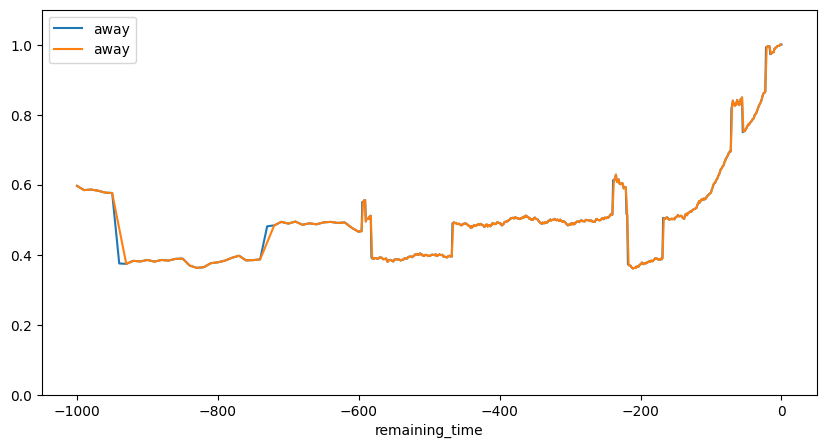

In [47]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

# df_real_games_1920\
# .query("period <= 4 & game_id == 41900405")\
# .reset_index(drop = True)\
# .pipe(preenche_dataframe, df_full = df_full)\
# .merge(df_indexador_1819, how = "left")\
# .query("period == 4")\
# [["period", "remaining_time", "dif", "posse", "away", "draw", "home"]]\
# .set_index("remaining_time")[["away"]].plot(ylim = [0, 1.1], ax = ax)

df_real_games_1920\
.query("period <= 4 & game_id == 41900405")\
.reset_index(drop = True)\
.pipe(preenche_dataframe, df_full = df_full)\
.merge(df_indexador_1819, how = "left")\
.query("period == 4 & remaining_time <= 1000")\
.assign(remaining_time = lambda df: -df["remaining_time"])\
[["period", "remaining_time", "dif", "posse", "away", "draw", "home"]]\
.set_index("remaining_time")[["away"]].plot(ylim = [0, 1.1], ax = ax)

df_real_games_1920\
.query("period <= 4 & game_id == 41900405")\
.reset_index(drop = True)\
.pipe(preenche_dataframe, df_full = df_full)\
.merge(df_indexador_1819, how = "left")\
.query("period == 4 & remaining_time <= 1000 & token_obj.isna()")\
.assign(remaining_time = lambda df: -df["remaining_time"])\
[["period", "remaining_time", "dif", "posse", "away", "draw", "home"]]\
.set_index("remaining_time")[["away"]].plot(ylim = [0, 1.1], ax = ax)

# df_real_games_1920\
# .query("period <= 4 & game_id == 41900405")\
# .reset_index(drop = True)\
# .pipe(preenche_dataframe, df_full = df_full)\
# .merge(df_indexador_1819, how = "left")\
# .query("period == 4 & token.isna() & posse == -1")\
# [["period", "remaining_time", "dif", "posse", "away", "draw", "home"]]\
# .set_index("remaining_time")[["away"]].plot(ylim = [0, 1.1], ax = ax)



In [48]:
df_real_games_1920\
.query("period <= 4 & game_id == 41900405")\
.reset_index(drop = True)\
.pipe(preenche_dataframe, df_full = df_full)\
.merge(df_indexador_1819, how = "left")\
.assign(dif_away = lambda df: df["away"] - df["away"].shift(1))\
.query("period == 4 & remaining_time <= 240")\
[["period", "clock", "remaining_time", "home_points", "away_points", "dif", "posse", "token_obj", "away", "draw", "home", "dif_away"]]\
.iloc[:60]

,period,clock,remaining_time,home_points,away_points,dif,posse,token_obj,away,draw,home,dif_away
4803,4,NaN,240,106.0,107.0,-1.0,1.0,NaN,0.513902,0.119847,0.366251,-0.001948
4804,4,00:23:90,239,106.0,107.0,-1.0,0.0,p400_2(5),0.612335,0.145374,0.242291,0.098433
4805,4,NaN,238,106.0,107.0,-1.0,0.0,NaN,0.607930,0.145374,0.246696,-0.004405
4806,4,NaN,237,106.0,107.0,-1.0,0.0,NaN,0.616071,0.142857,0.241071,0.008142
4807,4,NaN,236,106.0,107.0,-1.0,0.0,NaN,0.617391,0.134783,0.247826,0.001320
4808,4,NaN,235,106.0,107.0,-1.0,0.0,NaN,0.628319,0.128319,0.243363,0.010927
4809,4,NaN,234,106.0,107.0,-1.0,0.0,NaN,0.612069,0.129310,0.258621,-0.016250
4810,4,NaN,233,106.0,107.0,-1.0,0.0,NaN,0.606987,0.135371,0.257642,-0.005082
4811,4,NaN,232,106.0,107.0,-1.0,0.0,NaN,0.611872,0.132420,0.255708,0.004885
4812,4,NaN,231,106.0,107.0,-1.0,0.0,NaN,0.614679,0.128440,0.256881,0.002807


In [49]:
df_resultados

NameError: name 'df_resultados' is not defined

<Axes: >

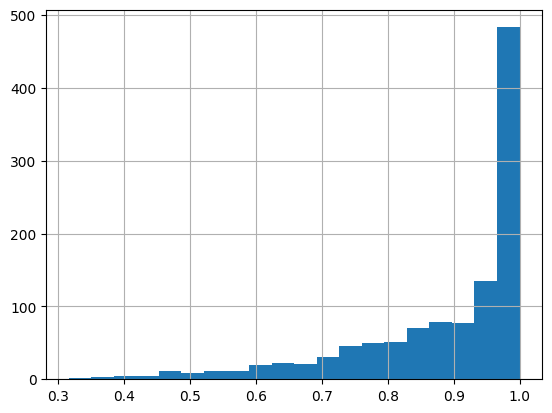

In [50]:
df_turning_points_1920\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 20)

<Axes: >

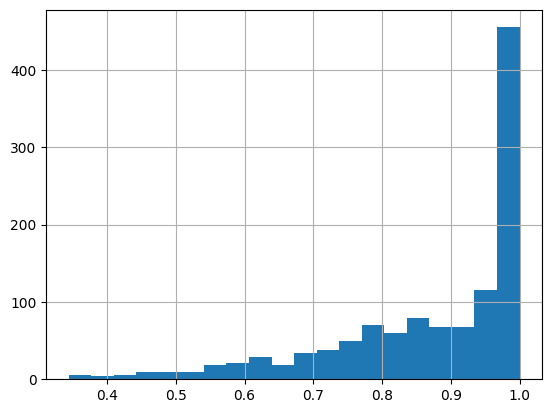

In [51]:
df_turning_points_2021\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 20)

<Axes: >

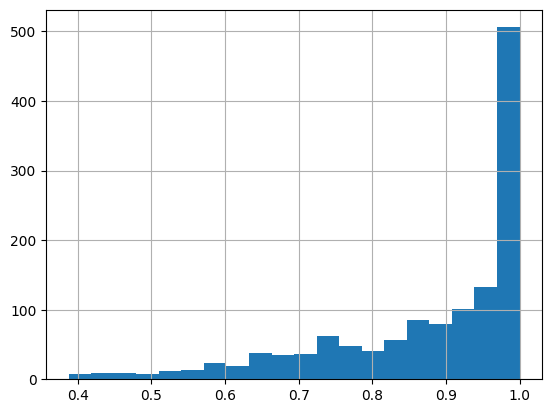

In [52]:
df_turning_points_2122\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 20)

<Axes: >

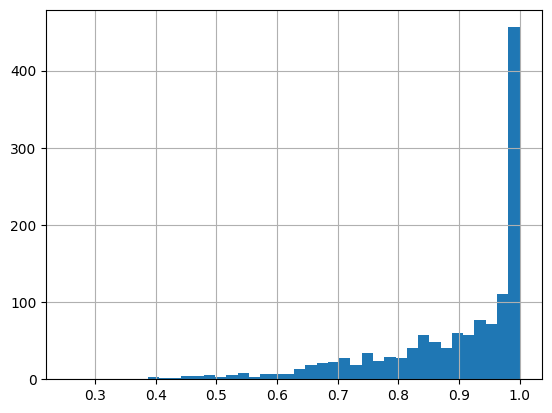

In [53]:
df_turning_points_2223\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 40)

In [54]:
df_turning_points_2324

,game_id,index,period,remaining_time,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse_antes,posse_depois,posse,total,ind_turning,away,draw,home,condicao
0,22300001,0,4,104,00:10:40,145.0,117.0,13.0,0.0,1.0,117.0,114.0,3.0,1.0,338.0,22300001.0,p500_2(5),p500_2(5),_2,338.0,338.0,p400_4(0p)p541_6(10a),p300_4(0t),-1.0,0.0,0.0,274.0,1.0,0.000000,0.032847,0.967153,1
0,22300002,0,4,252,NaN,NaN,NaN,NaN,NaN,NaN,107.0,103.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1040.0,1.0,0.024038,0.025000,0.950962,1
0,22300003,0,3,740,NaN,NaN,NaN,NaN,NaN,NaN,94.0,79.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,787.0,1.0,0.030496,0.016518,0.952986,1
0,22300004,0,4,9,NaN,NaN,NaN,NaN,NaN,NaN,107.0,109.0,-2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1302.0,1.0,0.953149,0.034562,0.012289,1
0,22300005,0,4,9,NaN,NaN,NaN,NaN,NaN,NaN,139.0,139.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1336.0,1.0,0.047904,0.951347,0.000749,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,22301226,0,4,1070,01:47:00,239.0,1130.0,60.0,1.0,1.0,112.0,120.0,-8.0,-1.0,367.0,22301226.0,p400_4(0p),p400_4(0p),_4,367.0,367.0,p400_2(4),p500_2(5),0.0,1.0,1.0,794.0,1.0,0.963476,0.020151,0.016373,1
0,22301227,0,4,2570,04:17:00,239.0,2580.0,10.0,0.0,2.0,121.0,112.0,9.0,1.0,317.0,22301227.0,p400_4(0p),p400_4(0p),_4,317.0,317.0,p541_6(11a)p400_3(12c)p400_3(22c),p500_2(5),0.0,1.0,1.0,1158.0,1.0,0.020725,0.019862,0.959413,1
0,22301228,0,4,1830,NaN,NaN,NaN,NaN,NaN,NaN,98.0,107.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,905.0,1.0,0.956906,0.015470,0.027624,1
0,22301229,0,4,593,00:59:30,240.0,620.0,27.0,0.0,0.0,114.0,119.0,-5.0,1.0,373.0,22301229.0,p500_4(0p),p500_4(0p),_4,373.0,373.0,p500_1(5),p500_2(5),0.0,-1.0,-1.0,1307.0,1.0,0.951033,0.026779,0.022188,1


<Axes: >

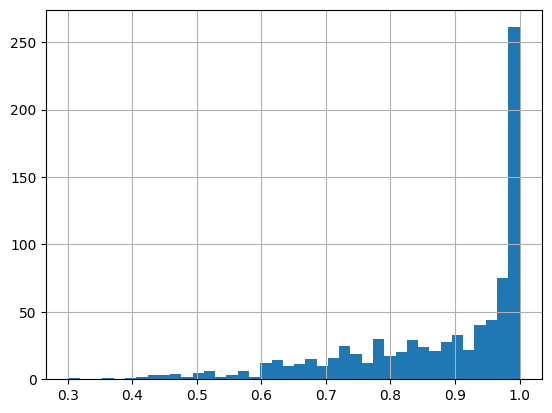

In [55]:
df_turning_points_2324\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
["prop_time"].hist(bins = 40)

In [56]:
df_resultados = pd.concat(objs = [df_turning_points_1920, df_turning_points_2021, df_turning_points_2122, df_turning_points_2223, df_turning_points_2324], axis = 0)\
.assign(time = lambda df: ((df["period"] - 1) * 7200) + (7200 - df["remaining_time"]))\
.assign(prop_time = lambda df: df["time"] / 28800)\
.assign(hpts = lambda df: df.groupby("game_id")["home_points"].transform("max"))\
.assign(apts = lambda df: df.groupby("game_id")["away_points"].transform("max"))\
.assign(outcome = "draw")\
.assign(outcome = lambda df: np.where(df["hpts"] > df["apts"], "home", df["outcome"]))\
.assign(outcome = lambda df: np.where(df["hpts"] < df["apts"], "away", df["outcome"]))\
.merge(df_games_nba[["game_id", "season", "HOME_TEAM", "AWAY_TEAM", "SEASON_TYPE"]], how = "left")

In [ ]:
df_resultados

,game_id,index,period,remaining_time,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse_antes,posse_depois,posse,total,ind_turning,away,draw,home,condicao,time,prop_time,hpts,apts,outcome,season,HOME_TEAM,AWAY_TEAM,SEASON_TYPE
0,21900001,0,4,7,NaN,NaN,NaN,NaN,NaN,NaN,117.0,117.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1155.0,1.0,0.000866,0.952381,0.046753,1,28793,0.999757,117.0,117.0,draw,2019-20,Toronto Raptors,New Orleans Pelicans,Regular Season
1,21900002,0,4,1520,NaN,NaN,NaN,NaN,NaN,NaN,110.0,102.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1101.0,1.0,0.026340,0.021798,0.951862,1,27280,0.947222,110.0,102.0,home,2019-20,LA Clippers,Los Angeles Lakers,Regular Season
2,21900003,0,4,45,00:04:50,13.0,113.0,68.0,0.0,0.0,126.0,125.0,1.0,-1.0,370.0,21900003.0,p500_1(3),p500_1(3),_1,370.0,370.0,p000_13(4),p400_3(22c),-1.0,1.0,1.0,964.0,1.0,0.006224,0.009336,0.984440,1,28755,0.998437,126.0,125.0,home,2019-20,Charlotte Hornets,Chicago Bulls,Regular Season
3,21900004,0,4,1010,01:41:00,104.0,1100.0,90.0,0.0,0.0,103.0,110.0,-7.0,-1.0,338.0,21900004.0,p400_2(2),p400_2(2),_2,338.0,338.0,p500_4(0p),p550_1(2a),1.0,0.0,0.0,172.0,1.0,0.959302,0.011628,0.029070,1,27790,0.964931,103.0,110.0,away,2019-20,Indiana Pacers,Detroit Pistons,Regular Season
4,21900005,0,4,3990,NaN,NaN,NaN,NaN,NaN,NaN,83.0,71.0,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,967.0,1.0,0.031024,0.018614,0.950362,1,24810,0.861458,83.0,71.0,home,2019-20,Orlando Magic,Cleveland Cavaliers,Regular Season
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5776,22301226,0,4,1070,01:47:00,239.0,1130.0,60.0,1.0,1.0,112.0,120.0,-8.0,-1.0,367.0,22301226.0,p400_4(0p),p400_4(0p),_4,367.0,367.0,p400_2(4),p500_2(5),0.0,1.0,1.0,794.0,1.0,0.963476,0.020151,0.016373,1,27730,0.962847,112.0,120.0,away,2023-24,Portland Trail Blazers,Dallas Mavericks,Regular Season
5777,22301227,0,4,2570,04:17:00,239.0,2580.0,10.0,0.0,2.0,121.0,112.0,9.0,1.0,317.0,22301227.0,p400_4(0p),p400_4(0p),_4,317.0,317.0,p541_6(11a)p400_3(12c)p400_3(22c),p500_2(5),0.0,1.0,1.0,1158.0,1.0,0.020725,0.019862,0.959413,1,26230,0.910764,121.0,112.0,home,2023-24,Boston Celtics,New York Knicks,Regular Season
5778,22301228,0,4,1830,NaN,NaN,NaN,NaN,NaN,NaN,98.0,107.0,-9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,905.0,1.0,0.956906,0.015470,0.027624,1,26970,0.936458,98.0,107.0,away,2023-24,Phoenix Suns,Sacramento Kings,Regular Season
5779,22301229,0,4,593,00:59:30,240.0,620.0,27.0,0.0,0.0,114.0,119.0,-5.0,1.0,373.0,22301229.0,p500_4(0p),p500_4(0p),_4,373.0,373.0,p500_1(5),p500_2(5),0.0,-1.0,-1.0,1307.0,1.0,0.951033,0.026779,0.022188,1,28207,0.979410,114.0,119.0,away,2023-24,Milwaukee Bucks,Indiana Pacers,Regular Season


In [57]:
df_resultados.groupby("season")["prop_time"].describe()\
.assign(mins_mean = lambda df: df["mean"] * 48)\
.assign(mins_med = lambda df: df["50%"] * 48)

,count,mean,std,min,25%,50%,75%,max,mins_mean,mins_med
season,,,,,,,,,,
2019-20,1142.0,0.885072,0.138711,0.316319,0.819097,0.947222,0.992465,0.999896,42.483433,45.466667
2020-21,1168.0,0.870027,0.145887,0.344097,0.788194,0.927083,0.992396,1.000000,41.761311,44.500000
2021-22,1322.0,0.875403,0.142099,0.387500,0.791753,0.931250,0.991762,0.999965,42.019365,44.700000
2022-23,1320.0,0.888942,0.130211,0.256250,0.825260,0.936806,0.992135,0.999965,42.669211,44.966667
2023-24,829.0,0.873214,0.142253,0.301389,0.784375,0.934028,0.991250,0.999965,41.914252,44.833333


In [ ]:
0.879004*48

42.192192

In [ ]:
df_resultados\
.groupby(["outcome", "season"], as_index = False, dropna = False)["prop_time"].describe()

,outcome,season,count,mean,std,min,25%,50%,75%,max
0,away,2019-20,480.0,0.897536,0.115655,0.454167,0.844965,0.946007,0.987543,0.999826
1,away,2020-21,497.0,0.875598,0.135138,0.376736,0.794097,0.923264,0.988090,0.999757
2,away,2021-22,567.0,0.886996,0.129922,0.416319,0.826042,0.936458,0.993021,0.999965
3,away,2022-23,507.0,0.900288,0.116923,0.406597,0.841840,0.945139,0.992639,0.999757
4,away,2023-24,352.0,0.890482,0.125421,0.428125,0.815278,0.952778,0.988446,0.999965
5,draw,2019-20,73.0,0.999674,0.000074,0.999583,0.999618,0.999618,0.999757,0.999757
6,draw,2020-21,60.0,0.999779,0.000086,0.999722,0.999722,0.999757,0.999757,1.000000
7,draw,2021-22,58.0,0.999765,0.000071,0.999722,0.999722,0.999757,0.999757,0.999965
8,draw,2022-23,85.0,0.999739,0.000100,0.999687,0.999687,0.999687,0.999687,0.999965
9,draw,2023-24,43.0,0.999761,0.000120,0.999687,0.999687,0.999687,0.999913,0.999965


In [ ]:
df_resultados.query("AWAY_TEAM == 'Los Angeles Lakers' & season == '2019-20'")\
[["game_id", "period", "remaining_time", "dif", "outcome", "away", "draw", "home", "prop_time"]]

,game_id,period,remaining_time,dif,outcome,away,draw,home,prop_time
1,21900002,4,1520,8.0,home,0.026340,0.021798,0.951862,0.947222
73,21900074,4,41,3.0,home,0.004219,0.045570,0.950211,0.998576
87,21900088,4,1050,-8.0,away,0.977528,0.016854,0.005618,0.963542
99,21900100,4,2930,-10.0,away,0.951469,0.019157,0.029374,0.898264
149,21900151,4,555,-5.0,away,0.962617,0.016822,0.020561,0.980729
218,21900220,4,28,-3.0,away,0.950476,0.049524,0.000000,0.999028
230,21900232,4,9,-1.0,away,0.952183,0.006237,0.041580,0.999687
247,21900249,4,2390,-9.0,away,0.953020,0.020134,0.026846,0.917014
262,21900264,4,42,-4.0,away,0.998037,0.001963,0.000000,0.998542
302,21900304,4,710,-6.0,away,0.951479,0.020118,0.028402,0.975347


In [58]:
df_resultados\
.assign(team = lambda df: np.where(df["outcome"] == "away", df["HOME_TEAM"], "draw"))\
.assign(team = lambda df: np.where(df["outcome"] == "home", df["AWAY_TEAM"], df["team"]))\
.groupby(["season", "team"], as_index = False, dropna = False)["prop_time"].describe()\
.query("season == '2022-23'")\
.sort_values("mean", ascending = False)

,season,team,count,mean,std,min,25%,50%,75%,max
123,2022-23,draw,85.0,0.999739,0.000100,0.999687,0.999687,0.999687,0.999687,0.999965
98,2022-23,Cleveland Cavaliers,35.0,0.923440,0.113938,0.447222,0.902083,0.970139,0.997882,0.999722
121,2022-23,Utah Jazz,42.0,0.921344,0.102624,0.605903,0.887326,0.967708,0.992995,0.999722
99,2022-23,Dallas Mavericks,41.0,0.915639,0.108566,0.553819,0.840278,0.973958,0.998646,0.999618
113,2022-23,Oklahoma City Thunder,40.0,0.910001,0.105782,0.576042,0.848785,0.949132,0.989201,0.999653
97,2022-23,Chicago Bulls,40.0,0.908046,0.108268,0.633681,0.849740,0.956597,0.994800,0.999722
118,2022-23,Sacramento Kings,38.0,0.906923,0.107394,0.544097,0.836111,0.944444,0.994783,0.999722
115,2022-23,Philadelphia 76ers,30.0,0.906806,0.116679,0.532292,0.870486,0.957639,0.978872,0.999375
112,2022-23,New York Knicks,34.0,0.904596,0.096218,0.673611,0.866059,0.928993,0.984444,0.999653
100,2022-23,Denver Nuggets,32.0,0.903996,0.117987,0.492396,0.861458,0.947569,0.993073,0.999653


<Axes: ylabel='Density'>

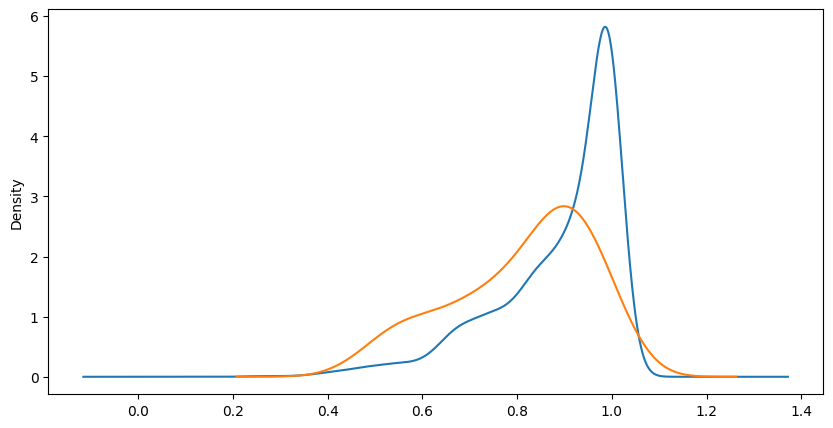

In [59]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))
df_resultados.query("season == '2022-23'")["prop_time"].plot(kind = "density", ax = ax)

df_resultados\
.assign(team = lambda df: np.where(df["outcome"] == "away", df["HOME_TEAM"], "draw"))\
.assign(team = lambda df: np.where(df["outcome"] == "home", df["AWAY_TEAM"], df["team"]))\
.query("season == '2022-23' & team == 'San Antonio Spurs'")\
["prop_time"].plot(kind = "density", ax = ax)

In [60]:
df_resultados\
.assign(team = lambda df: np.where(df["outcome"] == "away", df["AWAY_TEAM"], "draw"))\
.assign(team = lambda df: np.where(df["outcome"] == "home", df["HOME_TEAM"], df["team"]))\
.groupby(["season", "team"], as_index = False, dropna = False)["prop_time"].describe()\
.query("season == '2022-23'")\
.sort_values("mean", ascending = False)

,season,team,count,mean,std,min,25%,50%,75%,max
123,2022-23,draw,85.0,0.999739,0.000100,0.999687,0.999687,0.999687,0.999687,0.999965
104,2022-23,Indiana Pacers,33.0,0.946094,0.066463,0.724306,0.924306,0.971181,0.996667,0.999549
96,2022-23,Charlotte Hornets,26.0,0.936262,0.097529,0.633681,0.928125,0.977465,0.990729,0.999722
108,2022-23,Miami Heat,54.0,0.923193,0.104623,0.602778,0.887760,0.967882,0.997839,0.999722
103,2022-23,Houston Rockets,21.0,0.922958,0.115911,0.576042,0.863194,0.973958,0.993507,0.999722
101,2022-23,Detroit Pistons,14.0,0.912701,0.107079,0.622917,0.888021,0.951389,0.986007,0.999618
121,2022-23,Utah Jazz,33.0,0.911931,0.100985,0.687153,0.841667,0.953472,0.991007,0.999722
114,2022-23,Orlando Magic,32.0,0.906335,0.106721,0.540278,0.863628,0.941493,0.983446,0.999722
119,2022-23,San Antonio Spurs,21.0,0.903616,0.105584,0.595486,0.834028,0.950694,0.986493,0.999722
110,2022-23,Minnesota Timberwolves,42.0,0.900493,0.112516,0.642708,0.835069,0.948438,0.995773,0.999653


In [61]:
df_resultados\
.assign(cat = "")\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.75), "3. até o fim do terceiro periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.875), "4. até a primeira metade do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9583333), "5. antes dos dois ultimos minutos do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9791666), "6. antes do ultimo minuto do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9930556), "7. antes dos ultimos 20secs do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9965277), "8. antes dos ultimos 10secs do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == ""), "9. nos ultimos 10secs do quarto periodo", df["cat"]))\
.groupby(["cat", "season"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby("season")["size"].transform("sum"))\
.assign(prop = lambda df: 100 * df["size"] / df["total"])\
.pivot_table(index = "cat", columns = "season", values = "prop", margins = True)\
.assign(prop_acm = lambda df: df["All"].cumsum())


season,2019-20,2020-21,2021-22,2022-23,2023-24,All,prop_acm
cat,,,,,,,
3. até o fim do terceiro periodo,16.374781,19.520548,20.423601,16.439394,20.868516,18.725368,18.725368
4. até a primeira metade do quarto periodo,18.739054,21.232877,17.019667,18.181818,17.852835,18.605250,37.330618
5. antes dos dois ultimos minutos do quarto periodo,20.140105,17.722603,19.818457,21.363636,17.973462,19.403653,56.734271
6. antes do ultimo minuto do quarto periodo,10.070053,6.849315,8.472012,8.787879,9.650181,8.765888,65.500159
7. antes dos ultimos 20secs do quarto periodo,10.420315,11.301370,11.875946,10.681818,12.303981,11.316686,76.816845
8. antes dos ultimos 10secs do quarto periodo,2.189142,3.339041,4.387292,3.636364,3.015682,3.313504,80.130349
9. nos ultimos 10secs do quarto periodo,22.066550,20.034247,18.003026,20.909091,18.335344,19.869651,100.000000
All,14.285714,14.285714,14.285714,14.285714,14.285714,14.285714,114.285714


In [62]:
df_resultados\
.assign(team = lambda df: np.where(df["outcome"] == "away", df["AWAY_TEAM"], "draw"))\
.assign(team = lambda df: np.where(df["outcome"] == "home", df["HOME_TEAM"], df["team"]))\
.assign(cat = "")\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.75), "3. até o fim do terceiro periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.875), "4. até a primeira metade do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9583333), "5. antes dos dois ultimos minutos do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9791666), "6. antes do ultimo minuto do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9930556), "7. antes dos ultimos 20secs do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == "") & (df["prop_time"] <= 0.9965277), "8. antes dos ultimos 10secs do quarto periodo", df["cat"]))\
.assign(cat = lambda df: np.where((df["cat"] == ""), "9. nos ultimos 10secs do quarto periodo", df["cat"]))\
.groupby(["cat", "season", "team"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby(["team", "season"])["size"].transform("sum"))\
.assign(prop = lambda df: 100 * df["size"] / df["total"])\
.query("cat.str.contains('^3.')")\
.pivot_table(index = "team", columns = "season", values = "prop")


season,2019-20,2020-21,2021-22,2022-23,2023-24
team,,,,,
Atlanta Hawks,16.666667,18.750000,28.260870,12.195122,10.000000
Boston Celtics,17.543860,20.000000,36.666667,26.984127,33.333333
Brooklyn Nets,21.875000,25.925926,15.909091,18.181818,19.047619
Charlotte Hornets,NaN,16.666667,20.930233,11.538462,NaN
Chicago Bulls,20.000000,16.129032,13.333333,13.888889,9.523810
Cleveland Cavaliers,6.666667,15.789474,28.571429,26.666667,23.529412
Dallas Mavericks,23.255814,25.000000,22.950820,27.272727,28.125000
Denver Nuggets,10.000000,32.608696,31.111111,20.000000,27.777778
Detroit Pistons,27.777778,10.526316,NaN,7.142857,NaN


In [63]:
df_resultados\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.assign(ind = lambda df: (df["prop_time"] >= 0.9930))\
.query("season == '2021-22' & SEASON_TYPE == 'Regular Season'")\
.sort_values(["game_id", "altura_temporada"])\
.reset_index(drop = True)\
.reset_index()\
.assign(media = lambda df: df["level_0"].rolling(window = 100, min_periods = 1).mean())

,level_0,game_id,index,period,remaining_time,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse_antes,posse_depois,posse,total,ind_turning,away,draw,home,condicao,time,prop_time,hpts,apts,outcome,season,HOME_TEAM,AWAY_TEAM,SEASON_TYPE,altura_temporada,ind,media
0,0,22100001,0,4,4830,NaN,NaN,NaN,NaN,NaN,NaN,106.0,93.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,945.0,1.0,0.030688,0.012698,0.956614,1,23970,0.832292,106.0,93.0,home,2021-22,Milwaukee Bucks,Brooklyn Nets,Regular Season,1,False,0.0
1,1,22100002,0,4,1840,03:04:00,144.0,2040.0,200.0,1.0,2.0,103.0,112.0,-9.0,1.0,370.0,22100002.0,p400_2(5),p400_2(5),_2,370.0,370.0,p500_4(0p),p550_1(3a),1.0,0.0,0.0,147.0,1.0,0.965986,0.013605,0.020408,1,26960,0.936111,103.0,112.0,away,2021-22,Los Angeles Lakers,Golden State Warriors,Regular Season,2,False,0.5
2,2,22100003,0,4,10,NaN,NaN,NaN,NaN,NaN,NaN,123.0,122.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1152.0,1.0,0.046007,0.000868,0.953125,1,28790,0.999653,123.0,122.0,home,2021-22,Charlotte Hornets,Indiana Pacers,Regular Season,3,True,1.0
3,3,22100004,0,4,409,00:40:90,511.0,409.0,0.0,0.0,0.0,86.0,90.0,-4.0,1.0,345.0,22100004.0,p201_7(1t),p201_7(1t),_7,343.0,345.0,p400_2(4),p451_6(10p)p500_3(12c)p500_3(22c),-1.0,-1.0,-1.0,1121.0,1.0,0.964318,0.019625,0.016057,1,28391,0.985799,86.0,90.0,away,2021-22,Detroit Pistons,Chicago Bulls,Regular Season,4,False,1.5
4,4,22100005,0,4,7,NaN,NaN,NaN,NaN,NaN,NaN,116.0,116.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1187.0,1.0,0.000842,0.954507,0.044650,1,28793,0.999757,116.0,116.0,draw,2021-22,New York Knicks,Boston Celtics,Regular Season,5,True,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1225,1225,22101226,0,4,2270,NaN,NaN,NaN,NaN,NaN,NaN,92.0,82.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,189.0,1.0,0.031746,0.015873,0.952381,1,26530,0.921181,92.0,82.0,home,2021-22,New York Knicks,Toronto Raptors,Regular Season,1226,False,1175.5
1226,1226,22101227,0,4,4130,06:53:00,129.0,4290.0,160.0,4.0,1.0,112.0,99.0,13.0,1.0,294.0,22101227.0,p500_2(4),p500_2(4),_2,294.0,294.0,p400_4(0p),p440_1(3a)p541_6(11a)p400_3(11c),-1.0,0.0,0.0,149.0,1.0,0.020134,0.000000,0.979866,1,24670,0.856597,112.0,99.0,home,2021-22,Orlando Magic,Miami Heat,Regular Season,1227,False,1176.5
1227,1227,22101228,0,4,2770,04:37:00,281.0,2890.0,120.0,3.0,3.0,108.0,98.0,10.0,1.0,309.0,22101228.0,p540_5(11p),p540_5(11p),_5,309.0,309.0,p400_1(3),p300_4(0t),-1.0,1.0,1.0,1075.0,1.0,0.019535,0.015814,0.964651,1,26030,0.903819,108.0,98.0,home,2021-22,Philadelphia 76ers,Detroit Pistons,Regular Season,1228,False,1177.5
1228,1228,22101229,0,4,201,NaN,NaN,NaN,NaN,NaN,NaN,107.0,110.0,-3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,1220.0,1.0,0.950000,0.043443,0.006557,1,28599,0.993021,107.0,110.0,away,2021-22,Phoenix Suns,Sacramento Kings,Regular Season,1229,True,1178.5


In [ ]:
df_games_nba.query("season == '2021-22'").sort_values("GAME_DATE")

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS,SEASON_TYPE
16519,22100001,1610612749,1610612751,Milwaukee Bucks,Brooklyn Nets,2021-10-19,2021-22,127,104,Regular Season
16520,22100002,1610612747,1610612744,Los Angeles Lakers,Golden State Warriors,2021-10-19,2021-22,114,121,Regular Season
16531,22100013,1610612757,1610612758,Portland Trail Blazers,Sacramento Kings,2021-10-20,2021-22,121,124,Regular Season
16530,22100012,1610612756,1610612743,Phoenix Suns,Denver Nuggets,2021-10-20,2021-22,98,110,Regular Season
16529,22100011,1610612762,1610612760,Utah Jazz,Oklahoma City Thunder,2021-10-20,2021-22,107,86,Regular Season
...,...,...,...,...,...,...,...,...,...,...
17831,42100402,1610612744,1610612738,Golden State Warriors,Boston Celtics,2022-06-05,2021-22,107,88,Playoffs
17832,42100403,1610612738,1610612744,Boston Celtics,Golden State Warriors,2022-06-08,2021-22,116,100,Playoffs
17833,42100404,1610612738,1610612744,Boston Celtics,Golden State Warriors,2022-06-10,2021-22,97,107,Playoffs
17834,42100405,1610612744,1610612738,Golden State Warriors,Boston Celtics,2022-06-13,2021-22,104,94,Playoffs


In [ ]:
df_resultados.groupby("season")["prop_time"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019-20,1143.0,0.885262,0.143045,0.304167,0.819965,0.953472,0.994861,0.999757
2020-21,1170.0,0.871179,0.150748,0.320833,0.792622,0.934549,0.994991,0.999792
2021-22,1323.0,0.874498,0.147879,0.267014,0.790104,0.939931,0.992969,0.999757
2022-23,1320.0,0.888133,0.138165,0.221528,0.828038,0.942708,0.995278,0.999757
2023-24,830.0,0.872243,0.147439,0.301389,0.780295,0.936285,0.993160,0.999722


In [ ]:
2880 * 0.8333

2399.904

In [ ]:
2880-2859

21

<Axes: xlabel='altura_temporada'>

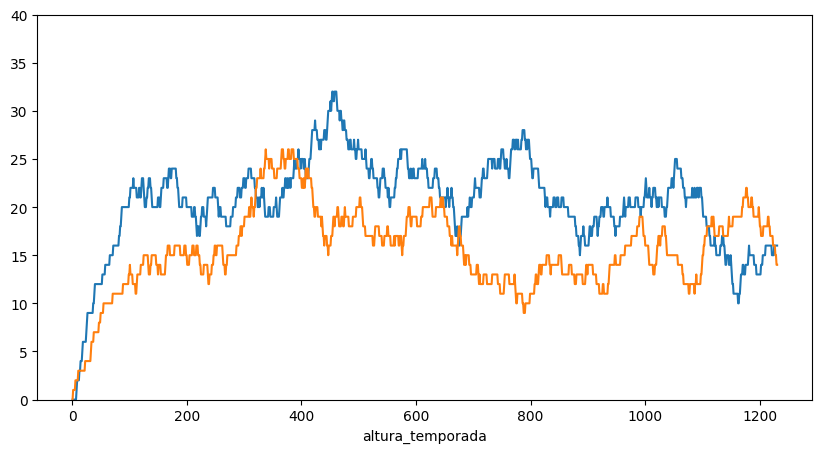

In [64]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.assign(ind = lambda df: (df["prop_time"] >= 0.9965))\
.query("season == '2022-23' & SEASON_TYPE == 'Regular Season'")\
.sort_values(["game_id", "altura_temporada"])\
.assign(media = lambda df: df["ind"].rolling(window = 100, min_periods = 1).sum())\
.set_index("altura_temporada")["media"].plot(ylim = [0.0, 40], ax = ax)

df_resultados\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.assign(ind = lambda df: (df["prop_time"] <= 0.75))\
.query("season == '2022-23' & SEASON_TYPE == 'Regular Season'")\
.sort_values(["game_id", "altura_temporada"])\
.assign(media = lambda df: df["ind"].rolling(window = 100, min_periods = 1).sum())\
.set_index("altura_temporada")["media"].plot(ax = ax)

# ax.axhline(100 * 0.5)
# ax.axhline(100 * 0.598)

In [65]:
df_resultados\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("season == '2022-23' & SEASON_TYPE == 'Regular Season'")\
.query("altura_temporada == 800")

,game_id,index,period,remaining_time,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse_antes,posse_depois,posse,total,ind_turning,away,draw,home,condicao,time,prop_time,hpts,apts,outcome,season,HOME_TEAM,AWAY_TEAM,SEASON_TYPE,altura_temporada
4431,22200800,0,4,690,01:09:00,239.0,720.0,30.0,0.0,1.0,116.0,111.0,5.0,1.0,332.0,22200800.0,p400_4(0p),p400_4(0p),_4,332.0,332.0,p541_6(11a)p400_3(12c)p400_3(22w),p400_2(4),0.0,1.0,1.0,1393.0,1.0,0.02369,0.018665,0.957645,1,28110,0.976042,116.0,111.0,home,2022-23,Golden State Warriors,Dallas Mavericks,Regular Season,800


In [ ]:
df_games_nba.query("game_id == 22200800")

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS,SEASON_TYPE
18641,22200800,1610612744,1610612742,Golden State Warriors,Dallas Mavericks,2023-02-04,2022-23,119,113,Regular Season


season
2019-20    Axes(0.125,0.11;0.775x0.77)
2020-21    Axes(0.125,0.11;0.775x0.77)
2021-22    Axes(0.125,0.11;0.775x0.77)
2022-23    Axes(0.125,0.11;0.775x0.77)
2023-24    Axes(0.125,0.11;0.775x0.77)
Name: prop_time, dtype: object

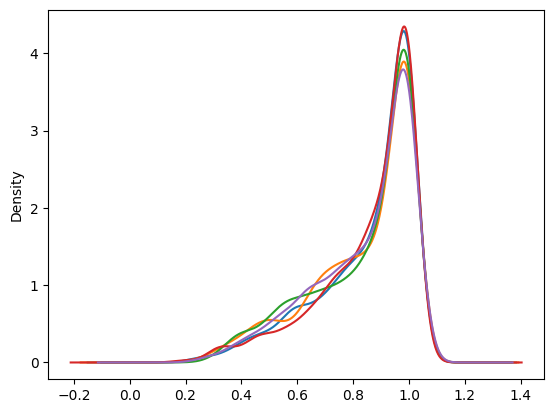

In [ ]:
df_resultados\
.groupby(["season"])["prop_time"].plot(kind = "density")

# \
# .query("outcome == 'home'")\
# .groupby(["season", "AWAY_TEAM"])["prop_time"].describe(percentiles = [.01, .05, .1, .25, .5, .75, .9, .95, .99])\
# .sort_values("mean")

season
2019-20    Axes(0.125,0.11;0.775x0.77)
2020-21    Axes(0.125,0.11;0.775x0.77)
2021-22    Axes(0.125,0.11;0.775x0.77)
2022-23    Axes(0.125,0.11;0.775x0.77)
2023-24    Axes(0.125,0.11;0.775x0.77)
Name: prop_time, dtype: object

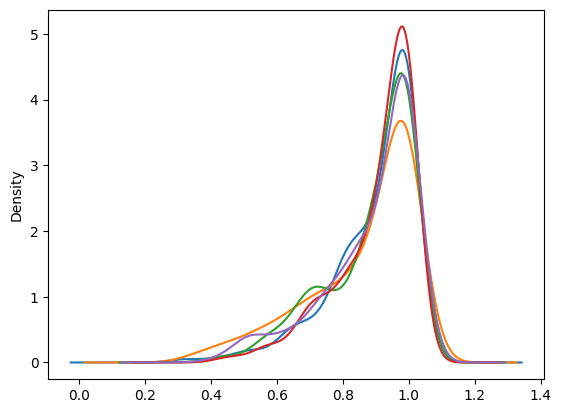

In [ ]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada <= 200")\
.groupby(["season"])["prop_time"].plot(kind = "density")


season
2019-20    Axes(0.125,0.11;0.775x0.77)
2020-21    Axes(0.125,0.11;0.775x0.77)
2021-22    Axes(0.125,0.11;0.775x0.77)
2022-23    Axes(0.125,0.11;0.775x0.77)
2023-24    Axes(0.125,0.11;0.775x0.77)
Name: prop_time, dtype: object

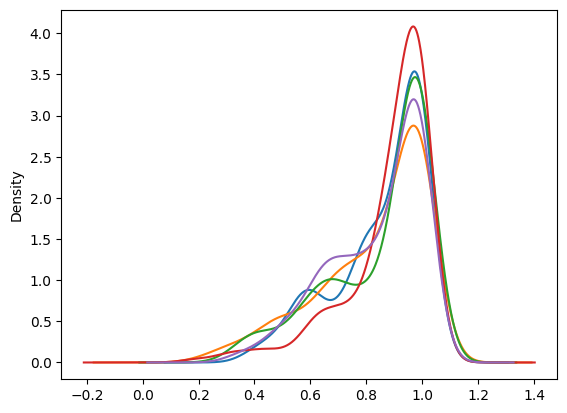

In [ ]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada >= 600 & altura_temporada <= 800")\
.groupby(["season"])["prop_time"].plot(kind = "density")

In [ ]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada <= 200")\
.groupby(["season"])["prop_time"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019-20,199.0,0.894277,0.129144,0.316319,0.826562,0.948958,0.992465,0.999896
2020-21,200.0,0.859634,0.163220,0.344097,0.757292,0.932813,0.991918,1.000000
2021-22,200.0,0.883641,0.132845,0.414931,0.815885,0.935764,0.993082,0.999965
2022-23,200.0,0.900429,0.118785,0.439931,0.837240,0.944444,0.992969,0.999965
2023-24,199.0,0.884703,0.139131,0.419444,0.815278,0.942361,0.995208,0.999965


In [ ]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada >= 600 & altura_temporada <= 800")\
.groupby(["season"])["prop_time"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019-20,200.0,0.851626,0.161171,0.385764,0.773611,0.915278,0.985234,0.999514
2020-21,201.0,0.822356,0.193521,0.216319,0.704861,0.889583,0.992847,0.999514
2021-22,201.0,0.845440,0.183325,0.325347,0.704861,0.941667,0.993854,0.999549
2022-23,201.0,0.878215,0.157349,0.192708,0.846181,0.935417,0.995347,0.999444
2023-24,195.0,0.835087,0.167314,0.344097,0.716146,0.894792,0.980312,0.999444


In [ ]:
df_resultados\
.query("SEASON_TYPE == 'Regular Season'")\
.assign(altura_temporada = lambda df: df["game_id"].astype("str").str[3:].astype("int"))\
.query("altura_temporada >= 1000")\
.groupby(["season"])["prop_time"].describe()

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
2019-20,88.0,0.863774,0.164551,0.357986,0.749653,0.935243,0.996771,0.999514
2020-21,81.0,0.792729,0.192675,0.360417,0.669444,0.837153,0.982049,0.999514
2021-22,231.0,0.813182,0.200022,0.321528,0.696875,0.872917,0.987795,0.999549
2022-23,231.0,0.842316,0.164836,0.264931,0.744062,0.894444,0.984306,0.999444
2023-24,30.0,0.857016,0.153479,0.429167,0.803906,0.900000,0.972396,0.999375


In [ ]:
df_games_nba

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS
0,20800001,1610612738,1610612739,Boston Celtics,Cleveland Cavaliers,2008-10-28,2008-09,90,85
1,20800002,1610612741,1610612749,Chicago Bulls,Milwaukee Bucks,2008-10-28,2008-09,108,95
2,20800003,1610612747,1610612757,Los Angeles Lakers,Portland Trail Blazers,2008-10-28,2008-09,96,76
3,20800004,1610612753,1610612737,Orlando Magic,Atlanta Hawks,2008-10-29,2008-09,85,99
4,20800005,1610612755,1610612761,Philadelphia 76ers,Toronto Raptors,2008-10-29,2008-09,84,95
...,...,...,...,...,...,...,...,...,...
20003,22301226,1610612757,1610612742,Portland Trail Blazers,Dallas Mavericks,2023-12-08,2023-24,112,125
20004,22301227,1610612738,1610612752,Boston Celtics,New York Knicks,2023-12-08,2023-24,133,123
20005,22301228,1610612756,1610612758,Phoenix Suns,Sacramento Kings,2023-12-08,2023-24,106,114
20006,22301229,1610612749,1610612754,Milwaukee Bucks,Indiana Pacers,2023-12-07,2023-24,119,128


In [ ]:
0.936285 * 2880

2696.5008000000003

In [ ]:
2696 // 60

44

## Figura: probabilidade dos desfechos ao longo da partida

Dois painéis empilhados com eixo x compartilhado. Nunca dois eixos y no mesmo painel.

**Painel superior** — as três probabilidades de desfecho, com rótulo direto na ponta de cada
linha em vez de legenda em caixa (melhor para impressão em escala de cinza). O limiar de 0,95
é uma linha de referência fina e o ponto de definição é a linha vertical: ele é o elemento
âncora da figura.

**Painel inferior** — a diferença de pontos em degraus e, colada ao eixo, a faixa de posse de
bola com os três estados. É aqui que o estado indefinido aparece visualmente.

**Anotações seletivas** — em vez das ~102 mudanças de posse e placar que um período tem em
média, rotulam-se apenas os `n_anotacoes` instantes de maior salto de probabilidade. Mantém o
mecanismo visível sem a parede de texto.

Cores: slots 1, 2 e 3 da paleta categórica de referência, em ordem fixa. A posse reusa as cores
das equipes, porque a cor segue a entidade, e o indefinido usa cinza neutro.

In [76]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# paleta categorica de referencia, ordem fixa (slots 1, 2, 3)
COR_DESFECHO = {"home": "#2a78d6", "away": "#eb6834", "draw": "#1baf7a"}
ROTULO_DESFECHO = {"home": "vitória do mandante", "away": "vitória do visitante",
                   "draw": "empate no fim do 4º"}
COR_POSSE = {1: "#2a78d6", -1: "#eb6834", 0: "#b8b8b4"}
ROTULO_POSSE = {1: "mandante", -1: "visitante", 0: "indefinida"}
TINTA, TINTA_SUAVE, GRADE = "#1a1a19", "#6b6b66", "#e4e4e0"


def prepara_partida(df_jogo, df_indexador, df_full_=None):
    """Grade temporal completa de uma partida, com as probabilidades do indexador.

    Diferente de `trecho_partida_resolvida`, NAO filtra pelo trecho resolvido:
    a figura precisa da trajetoria inteira.
    """
    if df_full_ is None:
        df_full_ = df_full
    traj = (df_jogo
            .reset_index(drop=True)
            .pipe(preenche_dataframe, df_full=df_full_)
            .merge(df_indexador, how="left")
            .pipe(calcula_turning_point)
            .sort_values(["period", "remaining_time"], ascending=[True, False])
            .reset_index(drop=True))
    return traj


def _mmss(decimos):
    seg = int(round(decimos / 10.0))
    return "%d:%02d" % (seg // 60, seg % 60)


def figura_probabilidade_partida(traj, periodos=(1, 2, 3, 4), n_anotacoes=4,
                                 titulo=None, caminho=None, figsize=(11, 6),
                                 limiar=0.95):
    """Figura de dois paineis: probabilidades de desfecho + placar e posse.

    traj        : saida de `prepara_partida`
    periodos    : tupla de periodos a exibir; um so periodo usa o eixo de tempo restante
    n_anotacoes : quantos instantes de maior salto de probabilidade rotular
    """
    d = traj[traj["period"].isin(periodos)].copy()
    d = d.sort_values(["period", "remaining_time"], ascending=[True, False]).reset_index(drop=True)

    colunas = [c for c in ("home", "away", "draw") if c in d.columns]
    if not colunas:
        raise ValueError("nao encontrei as colunas de desfecho (home/away/draw) na trajetoria")

    um_periodo = len(periodos) == 1
    if um_periodo:
        x = d["remaining_time"].values
    else:
        x = ((d["period"] - 1) * 7200 + (7200 - d["remaining_time"])).values

    fig, (ax, ax2) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

    # ---------------------------------------------------------------- painel de cima
    ax.axhline(limiar, color=TINTA_SUAVE, lw=0.8, zorder=1)
    ax.text(x[0], limiar, " limiar %.2f" % limiar, va="bottom", ha="left",
            fontsize=8, color=TINTA_SUAVE)

    for c in colunas:
        ax.plot(x, d[c].values, lw=2, color=COR_DESFECHO[c], zorder=3,
                solid_capstyle="round")
        # rotulo direto na ponta, em vez de legenda em caixa
        ax.annotate(ROTULO_DESFECHO[c], xy=(x[-1], d[c].values[-1]),
                    xytext=(6, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=9, color=COR_DESFECHO[c])

    # ponto de definicao: primeiro instante em que `condicao` passa a valer 1
    tp = d[d["condicao"] == 1]
    if len(tp):
        i_tp = tp.index[0]
        ax.axvline(x[i_tp], color=TINTA, lw=1.2, zorder=2)
        ax.annotate("ponto de definição\n%s do %dº período"
                    % (_mmss(d.loc[i_tp, "remaining_time"]), int(d.loc[i_tp, "period"])),
                    xy=(x[i_tp], 0.5), xytext=(8, 0), textcoords="offset points",
                    fontsize=8.5, color=TINTA, va="center")

    ax.set_ylim(-0.02, 1.02)
    ax.set_ylabel("probabilidade do desfecho", fontsize=9, color=TINTA)
    ax.grid(axis="y", color=GRADE, lw=0.8)
    ax.set_axisbelow(True)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color(GRADE)
    ax.tick_params(colors=TINTA_SUAVE, labelsize=8.5)
    if titulo:
        ax.set_title(titulo, fontsize=11, color=TINTA, loc="left", pad=12)

    # ------------------------------------------- anotacoes seletivas: maiores saltos
    p_max = d[colunas].max(axis=1).values
    salto = np.abs(np.diff(p_max, prepend=p_max[0]))
    mudou = (d["dif"].diff().fillna(0) != 0) | (d["posse"].diff().fillna(0) != 0)
    salto = np.where(mudou.values, salto, 0)
    for i in np.argsort(salto)[::-1][:n_anotacoes]:
        if salto[i] <= 0:
            continue
        partes = []
        if d["dif"].diff().fillna(0).iloc[i] != 0:
            partes.append("placar %+d" % int(d["dif"].iloc[i]))
        if d["posse"].diff().fillna(0).iloc[i] != 0:
            partes.append("posse %s" % ROTULO_POSSE.get(int(d["posse"].iloc[i]), "?"))
        ax.annotate(", ".join(partes), xy=(x[i], p_max[i]),
                    xytext=(0, 16), textcoords="offset points",
                    ha="center", fontsize=8, color=TINTA_SUAVE,
                    arrowprops=dict(arrowstyle="-", color=GRADE, lw=0.8))

    # ---------------------------------------------------------------- painel de baixo
    ax2.step(x, d["dif"].values, where="post", lw=1.5, color=TINTA_SUAVE)
    ax2.axhline(0, color=GRADE, lw=0.8)
    ax2.set_ylabel("diferença\nde pontos", fontsize=9, color=TINTA)
    ax2.grid(axis="y", color=GRADE, lw=0.8)
    ax2.set_axisbelow(True)
    for lado in ("top", "right"):
        ax2.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax2.spines[lado].set_color(GRADE)
    ax2.tick_params(colors=TINTA_SUAVE, labelsize=8.5)

    # faixa de posse colada ao eixo inferior
    y0, y1 = ax2.get_ylim()
    altura = (y1 - y0) * 0.09
    base = y0 - altura * 1.6
    posse = d["posse"].fillna(0).astype(int).values
    ini = 0
    for i in range(1, len(posse) + 1):
        if i == len(posse) or posse[i] != posse[ini]:
            ax2.axhspan(base, base + altura, xmin=0, xmax=1, color="none")
            ax2.fill_between([x[ini], x[min(i, len(x) - 1)]], base, base + altura,
                             color=COR_POSSE.get(posse[ini], "#b8b8b4"),
                             lw=0, zorder=3)
            ini = i
    ax2.set_ylim(base - altura * 0.6, y1)
    ax2.text(x[0], base + altura / 2, "posse  ", va="center", ha="right",
             fontsize=8, color=TINTA_SUAVE)

    # legenda so da posse (as linhas de cima tem rotulo direto)
    ax2.legend(handles=[Line2D([0], [0], color=COR_POSSE[k], lw=6,
                               label=ROTULO_POSSE[k]) for k in (1, -1, 0)],
               loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=3,
               frameon=False, fontsize=8.5, labelcolor=TINTA_SUAVE)

    # ---------------------------------------------------------------- eixo x
    if um_periodo:
        ax2.invert_xaxis()          # tempo restante cai da esquerda para a direita
        ax2.set_xlabel("tempo restante no %dº período" % periodos[0],
                       fontsize=9, color=TINTA)
        ticks = np.linspace(x.max(), x.min(), 7)
    else:
        for p in periodos[1:]:
            ax.axvline((p - 1) * 7200, color=GRADE, lw=1)
            ax2.axvline((p - 1) * 7200, color=GRADE, lw=1)
        ax2.set_xlabel("tempo decorrido de jogo", fontsize=9, color=TINTA)
        ticks = np.arange(0, 7200 * len(periodos) + 1, 3600)
    ax2.set_xticks(ticks)
    ax2.set_xticklabels([_mmss(t if um_periodo else (t % 7200)) for t in ticks])

    fig.tight_layout()
    if caminho:
        fig.savefig(caminho, dpi=300, bbox_inches="tight", facecolor="white")
    return fig, (ax, ax2)


def figura_tres_partidas(trajs, titulos, caminho=None, **kw):
    """Painéis pequenos: uma partida por coluna, para mostrar a amplitude da medida
    (decidida cedo / decidida no estouro / foi para overtime) em vez de um caso isolado."""
    figs = []
    for traj, tit in zip(trajs, titulos):
        figs.append(figura_probabilidade_partida(traj, titulo=tit, **kw))
    return figs


In [137]:
# -*- coding: utf-8 -*-
"""
Trajetoria de probabilidades de desfecho — script independente.

NAO usa nada do notebook 21b: monta a grade de tempo, preenche o estado,
cruza com o indexador e calcula o ponto de definicao internamente.

Depende apenas de numpy, pandas e matplotlib.

ENTRADAS
--------
df_jogo : DataFrame de UMA partida real, com as colunas
          period, remaining_time, home_points, away_points
          e, opcionalmente, dif e posse.
          (e uma fatia de df_real_games_YYYY)

df_indexador : DataFrame com
          period, remaining_time, dif, posse, total, home, away, draw
          (e um dos df_indexador_YYYY)

USO
---
    traj = prepara_trajetoria(
        df_real_games_2223.query("game_id == 22200800"),
        df_indexador_2122,
        marginalizar_posse=True)

    figura_trajetoria(traj, periodos=(4,),
                      titulo="Golden State Warriors 119 x 113 Dallas Mavericks",
                      caminho="figura_sloan_trajetoria.png")
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COR = {"home": "#2a78d6", "away": "#eb6834", "draw": "#1baf7a"}
ROTULO = {"home": "Home win", "away": "Away win", "draw": "Tie at end of regulation"}
DESFECHOS = ["home", "away", "draw"]

DURACAO_PERIODO = 7200      # decimos de segundo
LIMITE_DIF = 25


def _mmss(decimos):
    seg = int(round(float(decimos) / 10.0))
    return "%d:%02d" % (seg // 60, seg % 60)


def marginaliza_posse(df_indexador):
    """Remove o estrato de posse, ponderando pelo numero de simulacoes da celula.

    A trajetoria indexada por posse salta a cada troca de posse, o que numa figura
    pequena le como ruido. Marginalizando, a curva fica lisa e continua sendo
    probabilidade estimada -- de um cenario que nao condiciona em quem tem a bola.
    A legenda da figura precisa dizer isso.
    """
    d = df_indexador.copy()
    for c in DESFECHOS:
        d[c] = d[c] * d["total"]
    g = (d.groupby(["period", "remaining_time", "dif"], as_index=False)
           .agg(dict([(c, "sum") for c in DESFECHOS] + [("total", "sum")])))
    for c in DESFECHOS:
        g[c] = g[c] / g["total"]
    return g


def prepara_trajetoria(df_jogo, df_indexador, periodos=(1, 2, 3, 4),
                       marginalizar_posse=False, limiar=0.95):
    """Grade completa da partida, com as probabilidades e o ponto de definicao."""
    d = df_jogo.copy()
    if "dif" not in d.columns:
        d["dif"] = d["home_points"] - d["away_points"]
    if "posse" not in d.columns:
        d["posse"] = 0.0

    d = d[d["period"].isin(periodos)]
    d = d[["period", "remaining_time", "home_points", "away_points", "dif", "posse"]]
    # um evento por instante: vale o estado apos o ultimo deles
    d = (d.sort_values(["period", "remaining_time"], ascending=[True, False])
           .drop_duplicates(["period", "remaining_time"], keep="last"))

    # grade completa de (periodo, tempo restante)
    grade = pd.DataFrame(
        [(p, t) for p in periodos for t in range(DURACAO_PERIODO, -1, -1)],
        columns=["period", "remaining_time"])

    traj = (grade.merge(d, on=["period", "remaining_time"], how="left")
                 .sort_values(["period", "remaining_time"], ascending=[True, False])
                 .reset_index(drop=True))
    # estado so depende do passado: ffill, nunca bfill
    for c in ("home_points", "away_points", "dif", "posse"):
        traj[c] = traj[c].ffill()
    traj["dif"] = traj["dif"].fillna(0).clip(-LIMITE_DIF, LIMITE_DIF)
    traj["posse"] = traj["posse"].fillna(0)

    idx = marginaliza_posse(df_indexador) if marginalizar_posse else df_indexador.copy()
    chaves = ["period", "remaining_time", "dif"] + ([] if marginalizar_posse else ["posse"])
    for c in chaves:
        traj[c] = traj[c].astype(float)
        idx[c] = idx[c].astype(float)

    traj = traj.merge(idx[chaves + DESFECHOS], on=chaves, how="left")
    traj = traj.sort_values(["period", "remaining_time"],
                            ascending=[True, False]).reset_index(drop=True)
    # celula vazia no indexador: carrega a ultima estimativa conhecida
    for c in DESFECHOS:
        traj[c] = traj[c].ffill()

    # ponto de definicao: primeiro instante a partir do qual o maximo das tres
    # probabilidades permanece >= limiar ate o fim
    acima = (traj[DESFECHOS].max(axis=1) >= limiar).fillna(False).values
    traj["condicao"] = np.minimum.accumulate(acima[::-1])[::-1].astype(int)
    return traj


def figura_trajetoria(traj, periodos=(4,), titulo=None, caminho=None,
                      figsize=(10, 5.5), limiar=0.95,
                      loc_legenda="center left", bbox_legenda=None,
                      y_anotacao=0.55, lado_anotacao="auto", desloc_anotacao=8,
                      intervalo_ticks=600,
                      marcar_mudancas_placar=True, cor_marcas="0.88",
                      lw_marcas=0.7, marcas_nos_dois=False):
    """
    loc_legenda     : qualquer `loc` do matplotlib ("upper left", "lower right",
                      "center", "best", ...). Com bbox_legenda, posiciona livre.
    bbox_legenda    : tupla (x, y) em fracao dos eixos, ex. (1.02, 1) joga a
                      legenda para fora, a direita. None usa so o loc.
    y_anotacao      : altura do texto do ponto de definicao, em probabilidade (0 a 1)
    lado_anotacao   : "auto", "left" ou "right" — de que lado da linha vertical
    desloc_anotacao : afastamento do texto em relacao a linha, em pontos
    intervalo_ticks : espacamento das marcas do eixo x, em decimos de segundo.
                      600 = 1 minuto, 300 = 30 segundos, 1200 = 2 minutos.
    marcar_mudancas_placar : traco vertical de fundo em cada instante em que a
                      diferenca de pontos muda, para o leitor ligar os dois
                      paineis. Vai no zorder 0, abaixo de tudo.
    cor_marcas      : cinza desses tracos. "0.88" e bem claro; "0.80" marca mais.
    marcas_nos_dois : repete os tracos tambem no painel de baixo.
    """
    d = (traj[traj["period"].isin(periodos)]
         .sort_values(["period", "remaining_time"], ascending=[True, False])
         .reset_index(drop=True))

    um = len(periodos) == 1
    x = (d["remaining_time"].values.astype(float) if um
         else ((d["period"] - 1) * DURACAO_PERIODO
               + (DURACAO_PERIODO - d["remaining_time"])).values.astype(float))

    fig, (ax, ax2) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12})

    # tracos de fundo nos instantes em que o placar muda
    if marcar_mudancas_placar:
        muda = np.flatnonzero(np.diff(d["dif"].values) != 0) + 1
        for j in muda:
            ax.axvline(x[j], color=cor_marcas, lw=lw_marcas, zorder=0)
            if marcas_nos_dois:
                ax2.axvline(x[j], color=cor_marcas, lw=lw_marcas, zorder=0)

    for c in DESFECHOS:
        ax.plot(x, d[c].values, lw=1.8, color=COR[c], label=ROTULO[c], zorder=3)
    ax.axhline(limiar, color="0.4", lw=1, ls="--", label="0.95 threshold", zorder=2)

    tp = d[d["condicao"] == 1]
    if len(tp):
        i = tp.index[0]
        ax.axvline(x[i], color="0.1", lw=1.3)
        if lado_anotacao == "auto":
            meio = (x.min() + x.max()) / 2
            a_direita = (x[i] < meio) if um else (x[i] > meio)
        else:
            a_direita = (lado_anotacao == "right")
        ax.annotate("Decision point: %s left in Q%d"
                    % (_mmss(d.loc[i, "remaining_time"]), int(d.loc[i, "period"])),
                    xy=(x[i], y_anotacao),
                    xytext=(-desloc_anotacao if a_direita else desloc_anotacao, 0),
                    textcoords="offset points",
                    ha="right" if a_direita else "left", va="center", fontsize=9)

    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.arange(0, 1.01, 0.10))
    ax.set_ylabel("Outcome probability")
    ax.grid(axis="y", lw=0.6, alpha=0.4)
    ax.set_axisbelow(True)
    if bbox_legenda is None:
        ax.legend(loc=loc_legenda, fontsize=9, framealpha=0.9)
    else:
        ax.legend(loc=loc_legenda, bbox_to_anchor=bbox_legenda, fontsize=9,
                  framealpha=0.9)
    if titulo:
        ax.set_title(titulo)

    ax2.step(x, d["dif"].values, where="post", lw=1.4, color="0.25")
    ax2.axhline(0, color="0.4", lw=1, ls=":")
    ax2.set_ylabel("Score\ndifference")
    ax2.grid(axis="y", lw=0.6, alpha=0.4)
    ax2.set_axisbelow(True)
    lim = max(6, int(np.abs(d["dif"]).max()) + 2)
    ax2.set_ylim(-lim, lim)

    if um:
        ax2.invert_xaxis()
        ax2.set_xlabel("Time remaining in Q%d" % periodos[0])
        topo = int(np.ceil(x.max() / intervalo_ticks) * intervalo_ticks)
        t = np.arange(topo, -1, -intervalo_ticks)
        ax2.set_xticks(t)
        ax2.set_xticklabels([_mmss(v) for v in t])
    else:
        for p in periodos[1:]:
            ax.axvline((p - 1) * DURACAO_PERIODO, color="0.8", lw=1)
            ax2.axvline((p - 1) * DURACAO_PERIODO, color="0.8", lw=1)
        ax2.set_xlabel("Game time")
        ax2.set_xticks([(p - 0.5) * DURACAO_PERIODO for p in periodos])
        ax2.set_xticklabels(["Q%d" % p for p in periodos])
        ax2.set_xlim(0, DURACAO_PERIODO * len(periodos))

    fig.tight_layout()
    if caminho:
        fig.savefig(caminho, dpi=300, bbox_inches="tight", facecolor="white")
    return fig, (ax, ax2)


In [100]:
df_games_nba.query("season == '2022-23'").sort_values("GAME_DATE")

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS,SEASON_TYPE
17842,22200001,1610612738,1610612755,Boston Celtics,Philadelphia 76ers,2022-10-18,2022-23,126,117,Regular Season
17843,22200002,1610612744,1610612747,Golden State Warriors,Los Angeles Lakers,2022-10-18,2022-23,123,109,Regular Season
17855,22200014,1610612758,1610612757,Sacramento Kings,Portland Trail Blazers,2022-10-19,2022-23,108,115,Regular Season
17854,22200013,1610612756,1610612742,Phoenix Suns,Dallas Mavericks,2022-10-19,2022-23,107,105,Regular Season
17853,22200012,1610612762,1610612743,Utah Jazz,Denver Nuggets,2022-10-19,2022-23,123,102,Regular Season
...,...,...,...,...,...,...,...,...,...,...
19151,42200401,1610612743,1610612748,Denver Nuggets,Miami Heat,2023-06-01,2022-23,104,93,Playoffs
19152,42200402,1610612743,1610612748,Denver Nuggets,Miami Heat,2023-06-04,2022-23,108,111,Playoffs
19153,42200403,1610612748,1610612743,Miami Heat,Denver Nuggets,2023-06-07,2022-23,94,109,Playoffs
19154,42200404,1610612748,1610612743,Miami Heat,Denver Nuggets,2023-06-09,2022-23,95,108,Playoffs


In [139]:
traj

,period,remaining_time,home_points,away_points,dif,posse,home,away,draw,condicao
0,4.0,7200.0,70.0,71.0,-1.0,1.0,0.477071,0.48003,0.042899,0
1,4.0,7199.0,70.0,71.0,-1.0,1.0,0.477071,0.48003,0.042899,0
2,4.0,7198.0,70.0,71.0,-1.0,1.0,0.477071,0.48003,0.042899,0
3,4.0,7197.0,70.0,71.0,-1.0,1.0,0.477071,0.48003,0.042899,0
4,4.0,7196.0,70.0,71.0,-1.0,1.0,0.477071,0.48003,0.042899,0
...,...,...,...,...,...,...,...,...,...,...
7196,4.0,4.0,94.0,89.0,5.0,1.0,1.000000,0.00000,0.000000,1
7197,4.0,3.0,94.0,89.0,5.0,1.0,1.000000,0.00000,0.000000,1
7198,4.0,2.0,94.0,89.0,5.0,1.0,1.000000,0.00000,0.000000,1
7199,4.0,1.0,94.0,89.0,5.0,1.0,1.000000,0.00000,0.000000,1


C:\Users\User\AppData\Local\Temp\ipykernel_9376\3161704577.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1000x550 with 2 Axes>,
 (<Axes: title={'center': 'NBA Finals 2022/23 Game 5. Denver Nuggets 94 x 89 Miami Heat'}, ylabel='Outcome probability'>,
  <Axes: xlabel='Time remaining in Q4', ylabel='Score\ndifference'>))

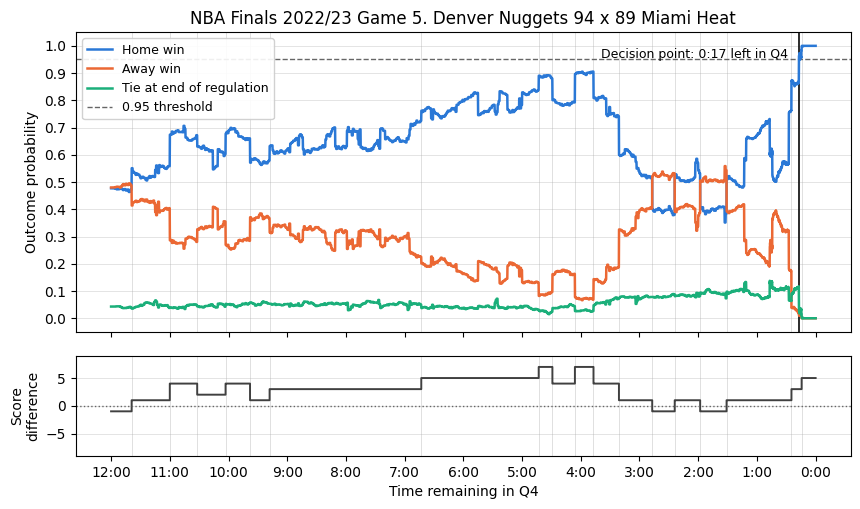

In [145]:
# curvas lisas (recomendado para a figura do abstract):
idx = marginaliza_posse(df_indexador_2122)
traj = prepara_trajetoria(df_real_games_2223.query("game_id == 42200405"), df_indexador_2122, periodos = (4, ))
figura_trajetoria(traj, periodos=(4,), titulo="NBA Finals 2022/23 Game 5. Denver Nuggets 94 x 89 Miami Heat", loc_legenda = "best", 
                  y_anotacao = 0.97,
                  caminho="figura_sloan_trajetoria.png", marcas_nos_dois=True)


In [78]:
df_games_nba.query("season == '2022-23'")

,game_id,HOME_TEAM_ID,AWAY_TEAM_ID,HOME_TEAM,AWAY_TEAM,GAME_DATE,season,HOME_PTS,AWAY_PTS,SEASON_TYPE
17842,22200001,1610612738,1610612755,Boston Celtics,Philadelphia 76ers,2022-10-18,2022-23,126,117,Regular Season
17843,22200002,1610612744,1610612747,Golden State Warriors,Los Angeles Lakers,2022-10-18,2022-23,123,109,Regular Season
17844,22200003,1610612765,1610612753,Detroit Pistons,Orlando Magic,2022-10-19,2022-23,113,109,Regular Season
17845,22200004,1610612754,1610612764,Indiana Pacers,Washington Wizards,2022-10-19,2022-23,107,114,Regular Season
17846,22200005,1610612737,1610612745,Atlanta Hawks,Houston Rockets,2022-10-19,2022-23,117,107,Regular Season
...,...,...,...,...,...,...,...,...,...,...
19157,52200111,1610612761,1610612741,Toronto Raptors,Chicago Bulls,2023-04-12,2022-23,105,109,Play-in
19158,52200121,1610612747,1610612750,Los Angeles Lakers,Minnesota Timberwolves,2023-04-11,2022-23,108,102,Play-in
19159,52200131,1610612740,1610612760,New Orleans Pelicans,Oklahoma City Thunder,2023-04-12,2022-23,118,123,Play-in
19160,52200201,1610612748,1610612741,Miami Heat,Chicago Bulls,2023-04-14,2022-23,102,91,Play-in


C:\Users\User\AppData\Local\Temp\ipykernel_9376\1687050157.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1100x600 with 2 Axes>,
 (<Axes: title={'left': 'Golden State Warriors 119 x 113 Dallas Mavericks'}, ylabel='probabilidade do desfecho'>,
  <Axes: xlabel='tempo restante no 4º período', ylabel='diferença\nde pontos'>))

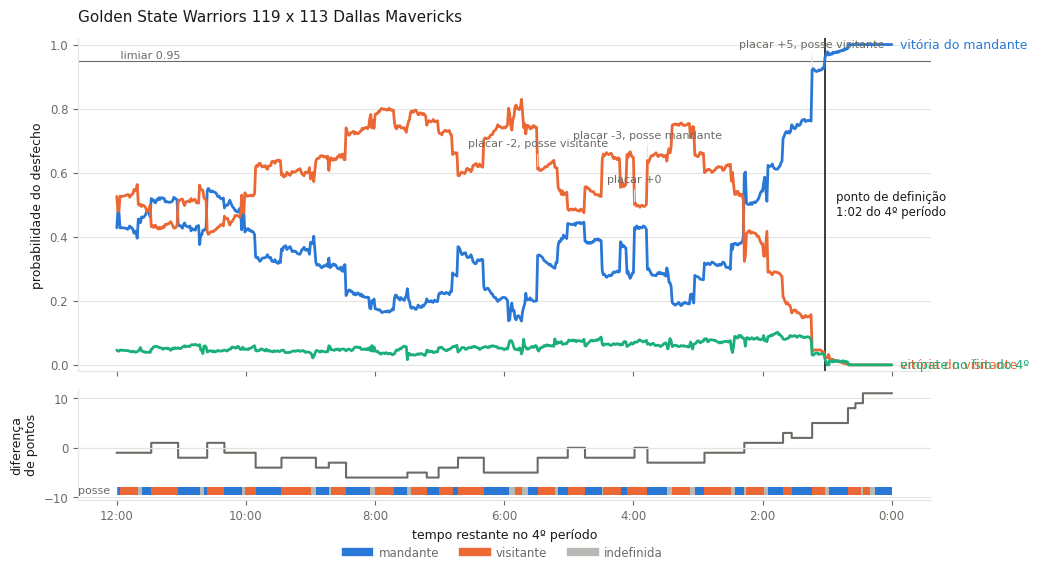

In [81]:
traj = prepara_partida(df_real_games_2223.query("game_id == 52200201"),
                       df_indexador_2122)
figura_probabilidade_partida(traj, periodos=(4,), titulo="Golden State Warriors 119 x 113 Dallas Mavericks",
                  caminho="figura_sloan_trajetoria.png")

In [74]:
df_real_games_2223

,game_id,period,clock,token,last_time,remaining_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse_antes,posse_depois,posse
0,22200001,1,12:00:00,87,7200,7200,0,4,4,0,0,0,-1.0,0,22200001,p000_12(1)p455_10(0),p000_12(1)p455_10(0),_12_10,0,0,p504_2(4b),,0,-1,-1
1,22200001,1,11:38:00,141,7200,6980,220,4,4,0,0,0,-1.0,1,22200001,p504_2(4b),p504_2(4b),_2,1,1,p500_4(0p),p000_12(1)p455_10(0),-1,0,0
3,22200001,1,11:35:00,323,6950,6950,0,4,4,0,0,0,-1.0,3,22200001,p501_5(32p),p501_5(32p),_5,2,3,p400_1(4),p500_4(0p),0,1,1
4,22200001,1,11:15:00,48,6950,6750,200,4,4,2,0,2,-1.0,4,22200001,p400_1(4),p400_1(4),_1,4,4,p500_2(4)p500_4(0p),p501_5(32p),1,-1,-1
5,22200001,1,11:05:00,133,6750,6650,100,4,4,2,0,2,-1.0,5,22200001,p500_2(4)p500_4(0p),p500_2(4)p500_4(0p),_2_4,5,5,p500_1(3),p400_1(4),-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472916,52200211,4,00:50:80,334,650,508,142,1,0,120,93,25,1.0,350,52200211,p540_5(35p),p540_5(35p),_5,350,350,p401_5(12p),p541_6(11p)p400_3(12c)p400_3(22c),-1,1,1
472917,52200211,4,00:47:50,282,508,475,33,1,0,120,93,25,1.0,351,52200211,p401_5(12p),p401_5(12p),_5,351,351,p550_1(3a),p540_5(35p),1,-1,-1
472918,52200211,4,00:37:70,29,475,377,98,1,0,120,95,25,1.0,352,52200211,p550_1(3a),p550_1(3a),_1,352,352,p201_5(37t),p401_5(12p),-1,1,1
472919,52200211,4,00:13:60,337,377,136,241,1,0,120,95,25,1.0,353,52200211,p201_5(37t),p201_5(37t),_5,353,353,p000_13(4),p550_1(3a),1,-1,-1


In [100]:
traj["total"].describe()

count     5044.000000
mean      1474.982355
std       3103.932368
min         44.000000
25%        684.750000
50%       1187.000000
75%       1347.000000
max      49034.000000
Name: total, dtype: float64

In [ ]:
# -*- coding: utf-8 -*-
# =========================================================================
# Figura da trajetoria de probabilidades — versao para o abstract do Sloan.
# Substitui `figura_probabilidade_partida` do notebook 21b.
#
# Mudancas pedidas:
#   - titulo no formato padrao do matplotlib
#   - caixa completa em volta dos dois paineis
#   - probabilidades com marcas de 0,10 em 0,10
#   - painel da diferenca de pontos tambem em caixa, com linha pontilhada em 0
#
# Mudancas que eu fiz por cima, porque eram defeitos na versao anterior:
#   - os rotulos das tres curvas se atropelavam na borda direita quando duas
#     delas convergiam; viraram legenda
#   - as anotacoes de placar/posse se empilhavam no fim do jogo; agora exigem
#     separacao minima no eixo x
#   - o eixo x repetia "0:00 6:00 0:00 6:00" sem dizer de que periodo; agora
#     ha divisoria e rotulo Q1..Q4
#   - a faixa de posse virava um codigo de barras ilegivel na escala do jogo
#     inteiro; saiu do padrao, mas volta com mostrar_posse=True
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

COR_DESFECHO = {"home": "#2a78d6", "away": "#eb6834", "draw": "#1baf7a"}
ROTULO_EN = {"home": "Home win", "away": "Away win", "draw": "Tied at the end of regulation"}
COR_POSSE = {1: "#2a78d6", -1: "#eb6834", 0: "#b8b8b4"}
ROTULO_POSSE_EN = {1: "Home", -1: "Away", 0: "Undefined"}


def _mmss(decimos):
    seg = int(round(decimos / 10.0))
    return "%d:%02d" % (seg // 60, seg % 60)


def figura_trajetoria(traj, periodos=(1, 2, 3, 4), n_anotacoes=4, titulo=None,
                      caminho=None, figsize=(11, 6), limiar=0.95,
                      mostrar_posse=False):
    d = traj[traj["period"].isin(periodos)].copy()
    d = d.sort_values(["period", "remaining_time"], ascending=[True, False]).reset_index(drop=True)

    colunas = [c for c in ("home", "away", "draw") if c in d.columns]
    um_periodo = len(periodos) == 1
    if um_periodo:
        x = d["remaining_time"].values.astype(float)
    else:
        x = ((d["period"] - 1) * 7200 + (7200 - d["remaining_time"])).values.astype(float)

    fig, (ax, ax2) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.10})

    # ------------------------------------------------------- painel superior
    for c in colunas:
        ax.plot(x, d[c].values, lw=2, color=COR_DESFECHO[c], zorder=3,
                label=ROTULO_EN[c])

    ax.axhline(limiar, color="0.35", lw=1, ls="--", zorder=2,
               label="0.95 threshold")

    tp = d[d["condicao"] == 1]
    if len(tp):
        i_tp = tp.index[0]
        ax.axvline(x[i_tp], color="0.15", lw=1.3, zorder=2)
        lado = "left" if x[i_tp] > (x.min() + x.max()) / 2 else "right"
        desloc = -8 if lado == "left" else 8
        ax.annotate("Decision point\n%s left in Q%d"
                    % (_mmss(d.loc[i_tp, "remaining_time"]), int(d.loc[i_tp, "period"])),
                    xy=(x[i_tp], 0.62), xytext=(desloc, 0),
                    textcoords="offset points", fontsize=9,
                    ha=("right" if lado == "left" else "left"), va="center")

    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.01, 0.10))
    ax.set_ylabel("Outcome probability")
    ax.grid(axis="y", lw=0.6, alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc="upper left", fontsize=9, ncol=2)
    if titulo:
        ax.set_title(titulo)

    # ------------------------------- anotacoes, com separacao minima no eixo x
    p_max = d[colunas].max(axis=1).values
    salto = np.abs(np.diff(p_max, prepend=p_max[0]))
    mudou = (d["dif"].diff().fillna(0) != 0) | (d["posse"].diff().fillna(0) != 0)
    salto = np.where(mudou.values, salto, 0.0)

    sep_min = (x.max() - x.min()) * 0.08
    escolhidos = []
    for i in np.argsort(salto)[::-1]:
        if salto[i] <= 0 or len(escolhidos) >= n_anotacoes:
            break
        if all(abs(x[i] - x[j]) > sep_min for j in escolhidos):
            escolhidos.append(i)

    for i in escolhidos:
        partes = []
        if d["dif"].diff().fillna(0).iloc[i] != 0:
            partes.append("%+d" % int(d["dif"].iloc[i]))
        if d["posse"].diff().fillna(0).iloc[i] != 0:
            partes.append(ROTULO_POSSE_EN.get(int(d["posse"].iloc[i]), "?") + " ball")
        if not partes:
            continue
        ax.annotate(", ".join(partes), xy=(x[i], p_max[i]),
                    xytext=(0, 18), textcoords="offset points",
                    ha="center", fontsize=8.5,
                    arrowprops=dict(arrowstyle="-", color="0.6", lw=0.8))

    # ------------------------------------------------------- painel inferior
    ax2.step(x, d["dif"].values, where="post", lw=1.5, color="0.25")
    ax2.axhline(0, color="0.35", lw=1, ls=":")
    ax2.set_ylabel("Score\ndifference")
    ax2.grid(axis="y", lw=0.6, alpha=0.5)
    ax2.set_axisbelow(True)

    lim = max(6, int(np.abs(d["dif"]).max()) + 2)
    ax2.set_ylim(-lim, lim)

    if mostrar_posse:
        posse = d["posse"].fillna(0).astype(int).values
        altura = lim * 0.16
        base = -lim - altura * 1.4
        ini = 0
        for i in range(1, len(posse) + 1):
            if i == len(posse) or posse[i] != posse[ini]:
                ax2.fill_between([x[ini], x[min(i, len(x) - 1)]], base, base + altura,
                                 color=COR_POSSE.get(posse[ini], "#b8b8b4"),
                                 lw=0, zorder=3)
                ini = i
        ax2.set_ylim(base - altura * 0.4, lim)
        ax2.legend(handles=[Line2D([0], [0], color=COR_POSSE[k], lw=6,
                                   label=ROTULO_POSSE_EN[k]) for k in (1, -1, 0)],
                   loc="lower center", bbox_to_anchor=(0.5, -0.55), ncol=3,
                   frameon=False, fontsize=8.5, title="Ball possession")

    # ------------------------------------------------------------------ eixo x
    if um_periodo:
        ax2.invert_xaxis()
        ax2.set_xlabel("Time remaining in Q%d" % periodos[0])
        ticks = np.linspace(x.max(), x.min(), 7)
        ax2.set_xticks(ticks)
        ax2.set_xticklabels([_mmss(t) for t in ticks])
    else:
        for p in periodos[1:]:
            ax.axvline((p - 1) * 7200, color="0.75", lw=1)
            ax2.axvline((p - 1) * 7200, color="0.75", lw=1)
        ax2.set_xlabel("Game time")
        ticks = [(p - 0.5) * 7200 for p in periodos]
        ax2.set_xticks(ticks)
        ax2.set_xticklabels(["Q%d" % p for p in periodos])
        ax2.set_xlim(0, 7200 * len(periodos))

    fig.tight_layout()
    if caminho:
        fig.savefig(caminho, dpi=300, bbox_inches="tight", facecolor="white")
    return fig, (ax, ax2)


# --------------------------------------------------------------------------
# USO
# traj = prepara_partida(df_real_games_2223.query("game_id == 22200800"),
#                        df_indexador_2122)
# figura_trajetoria(traj, titulo="Golden State Warriors 119 x 113 Dallas Mavericks",
#                   caminho="figura_sloan_trajetoria.png")


C:\Users\User\AppData\Local\Temp\ipykernel_20236\1687050157.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1100x600 with 2 Axes>,
 (<Axes: title={'left': 'Quarto período'}, ylabel='probabilidade do desfecho'>,
  <Axes: xlabel='tempo restante no 4º período', ylabel='diferença\nde pontos'>))

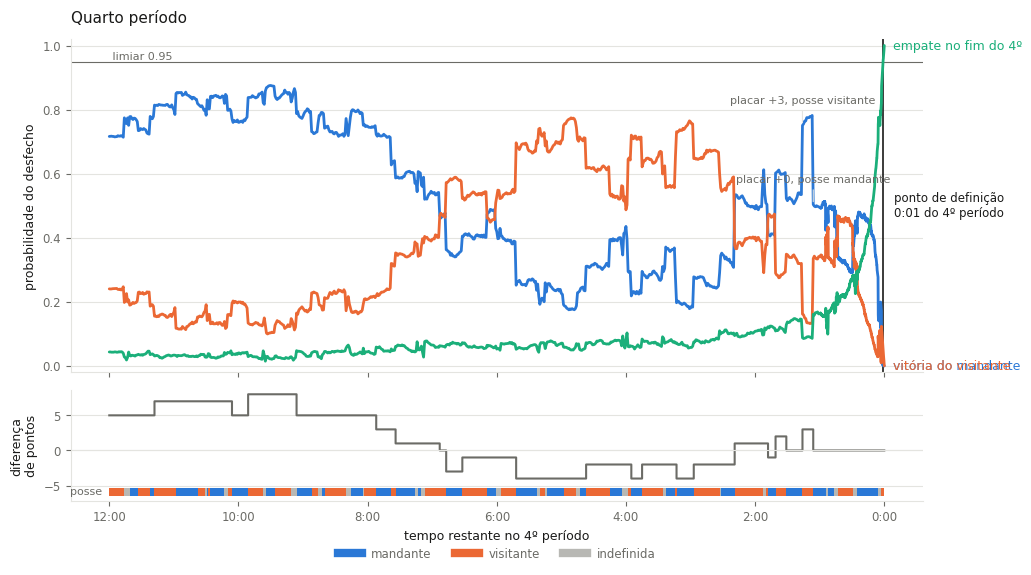

In [121]:
# --- exemplo de uso (rode depois de montar df_real_games_* e df_indexador_*)

jogo = df_real_games_1920.query("game_id == 21900006")
traj = prepara_partida(jogo, df_indexador_1819)

# a partida inteira
# figura_probabilidade_partida(traj, periodos=(1, 2, 3, 4),
#                              titulo="Evolução das probabilidades de desfecho",
#                              caminho="../img/prob_desfecho_partida.png")

# so o quarto periodo, com o eixo em tempo restante
figura_probabilidade_partida(traj, periodos=(4,), n_anotacoes=2,
                             titulo="Quarto período")


In [123]:
traj.query("period == 4 & game_id.notna()").iloc[-60:]

,period,remaining_time,game_id,clock,token,last_time,spent_time,limhfouls,limvfouls,home_points,away_points,dif,ball_possession,step,sim_id,token_,token_obj,tk_simp,min_step,max_step,next_token_obj,last_token_obj,posse_antes,posse_depois,posse,total,ind_turning,away,draw,home,condicao
3981,4,5220,21900006.0,08:42:00,239.0,5260.0,40.0,0.0,4.0,98.0,93.0,5.0,-1.0,311.0,21900006.0,p400_4(0p),p400_4(0p),_4,311.0,311.0,p401_5(34p),p500_2(5),0.0,1.0,1.0,1253,0,0.173982,0.035116,0.790902,0
3983,4,5200,21900006.0,08:40:00,327.0,5220.0,20.0,0.0,4.0,98.0,93.0,5.0,-1.0,312.0,21900006.0,p401_5(34p),p401_5(34p),_5,312.0,312.0,p500_2(5),p400_4(0p),1.0,-1.0,-1.0,1244,0,0.213023,0.045016,0.741961,0
4003,4,5000,21900006.0,08:20:00,145.0,5200.0,200.0,0.0,4.0,98.0,93.0,5.0,-1.0,313.0,21900006.0,p500_2(5),p500_2(5),_2,313.0,313.0,p400_4(0p),p401_5(34p),-1.0,0.0,0.0,215,0,0.172093,0.055814,0.772093,0
4008,4,4950,21900006.0,08:15:00,239.0,5000.0,50.0,0.0,4.0,98.0,93.0,5.0,-1.0,314.0,21900006.0,p400_4(0p),p400_4(0p),_4,314.0,314.0,p400_2(4),p500_2(5),0.0,1.0,1.0,1247,0,0.168404,0.036087,0.795509,0
4019,4,4840,21900006.0,08:04:00,128.0,4950.0,110.0,0.0,4.0,98.0,93.0,5.0,-1.0,315.0,21900006.0,p400_2(4),p400_2(4),_2,315.0,315.0,p500_4(0p),p400_4(0p),1.0,0.0,0.0,217,0,0.193548,0.055300,0.751152,0
4020,4,4830,21900006.0,08:03:00,240.0,4840.0,10.0,0.0,4.0,98.0,93.0,5.0,-1.0,316.0,21900006.0,p500_4(0p),p500_4(0p),_4,316.0,316.0,p451_6(10p)p500_3(12c)p500_3(22c),p400_2(4),0.0,-1.0,-1.0,1155,0,0.208658,0.038095,0.753247,0
4031,4,4720,21900006.0,07:52:00,385.0,4830.0,110.0,0.0,4.0,98.0,95.0,3.0,-1.0,318.0,21900006.0,p451_6(10p)p500_3(12c)p500_3(22c),p451_6(10p)p500_3(12c)p500_3(22c),_6_3,318.0,318.0,p450_5(11p),p500_4(0p),-1.0,1.0,1.0,1311,0,0.218917,0.058734,0.722349,0
4045,4,4580,21900006.0,07:38:00,280.0,4720.0,140.0,0.0,4.0,98.0,95.0,3.0,-1.0,319.0,21900006.0,p450_5(11p),p450_5(11p),_5,319.0,319.0,p500_1(3),p451_6(10p)p500_3(12c)p500_3(22c),1.0,-1.0,-1.0,1245,0,0.319679,0.053012,0.627309,0
4049,4,4540,21900006.0,07:34:00,13.0,4580.0,40.0,0.0,4.0,98.0,97.0,1.0,-1.0,320.0,21900006.0,p500_1(3),p500_1(3),_1,320.0,320.0,p400_2(4),p450_5(11p),-1.0,1.0,1.0,1265,0,0.352569,0.060870,0.586561,0
4067,4,4360,21900006.0,07:16:00,128.0,4540.0,180.0,0.0,4.0,98.0,97.0,1.0,-1.0,322.0,21900006.0,p400_2(4),p400_2(4),_2,322.0,322.0,p400_4(0p),p500_1(3),1.0,0.0,0.0,230,0,0.386957,0.043478,0.569565,0
